偏相关系数结果:
        Variable 1       Variable 2  Partial Correlation
0        AQI Value     CO AQI Value             0.002808
1        AQI Value  Ozone AQI Value             0.402641
2        AQI Value    NO2 AQI Value            -0.017512
3        AQI Value  PM2.5 AQI Value             0.981044
4     CO AQI Value  Ozone AQI Value             0.130957
5     CO AQI Value    NO2 AQI Value             0.450210
6     CO AQI Value  PM2.5 AQI Value             0.054239
7  Ozone AQI Value    NO2 AQI Value            -0.293051
8  Ozone AQI Value  PM2.5 AQI Value            -0.334127
9    NO2 AQI Value  PM2.5 AQI Value             0.049084


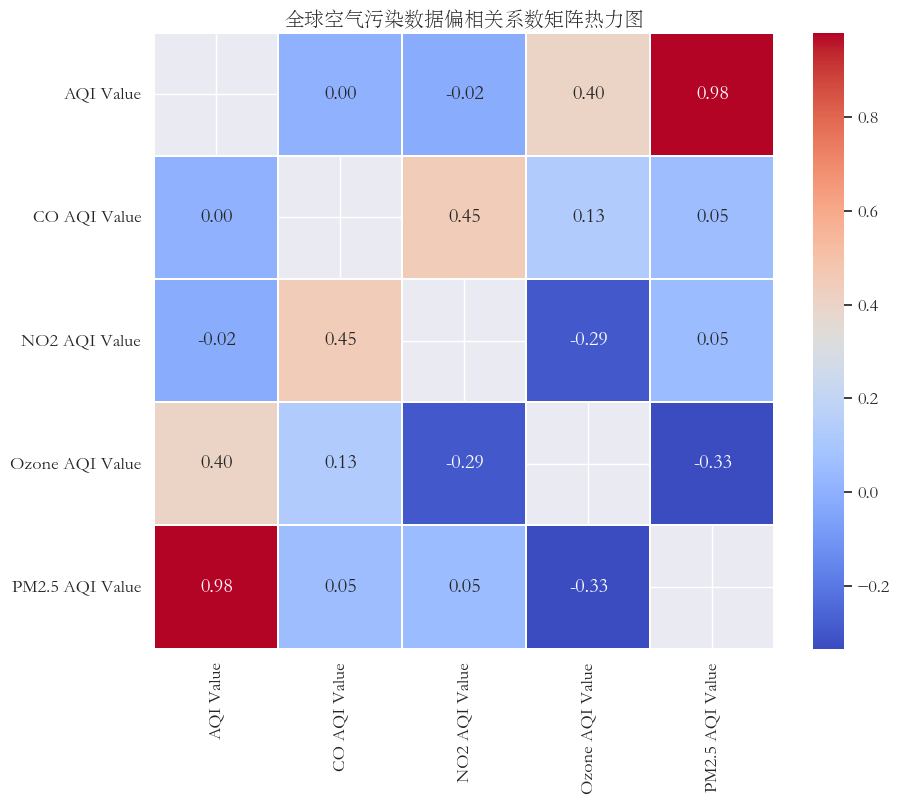

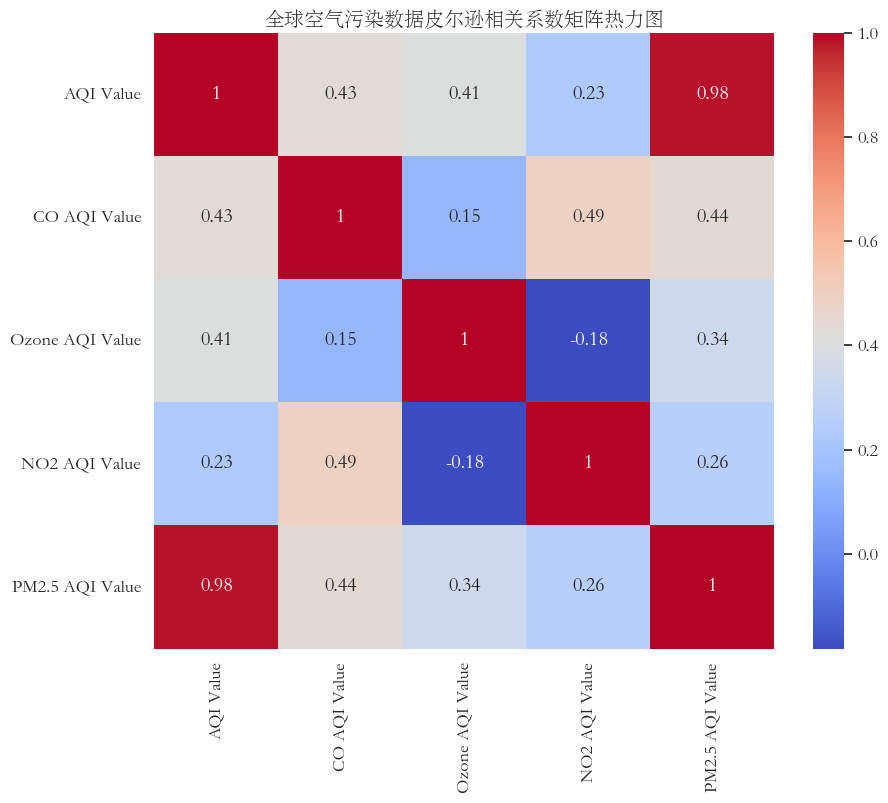

In [3]:
import pandas as pd
import numpy as np
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

# 读取数据集
data = pd.read_csv('F:/zhoumian/book/global air pollution dataset.csv')

# 选择要分析的列
columns_to_analyze = ['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']

# 缺失值处理
data = data[columns_to_analyze].dropna()

# 计算偏相关系数
partial_corr_result = pd.DataFrame({
    'Variable 1': [],
    'Variable 2': [],
    'Partial Correlation': []
})

for i, var1 in enumerate(columns_to_analyze):
    for var2 in columns_to_analyze[i+1:]:
        covar = [v for v in columns_to_analyze if v != var1 and v != var2]
        r = pg.partial_corr(data=data, x=var1, y=var2, covar=covar)
        new_row = pd.DataFrame({
            'Variable 1': [var1],
            'Variable 2': [var2],
            'Partial Correlation': [r.at['pearson', 'r']]
        })
        partial_corr_result = pd.concat([partial_corr_result, new_row], ignore_index=True)

# 打印偏相关系数结果
print("偏相关系数结果:")
print(partial_corr_result)

# 转换偏相关系数结果为矩阵格式
partial_corr_matrix = partial_corr_result.pivot(index='Variable 1', columns='Variable 2', values='Partial Correlation')
partial_corr_matrix = partial_corr_matrix.combine_first(partial_corr_matrix.T)

# 绘制偏相关系数热力图
sns.set(font='STSong', font_scale=1.2)
plt.figure(figsize=(10, 8))
sns.heatmap(partial_corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', linewidths=.05)
plt.title('全球空气污染数据偏相关系数矩阵热力图')
plt.savefig('F:/zhoumian/book/偏相关系数热力图_air_pollution_data.svg', dpi=300, pad_inches=0.3, bbox_inches='tight')
plt.show()

# 计算皮尔逊相关系数矩阵
corr_matrix_subset = data[columns_to_analyze].corr()

# 可视化皮尔逊相关系数矩阵热力图
plt.figure(figsize=(10, 8))
sns.set(font='STSong', font_scale=1.2)
sns.heatmap(corr_matrix_subset, annot=True, cmap='coolwarm')
plt.title('全球空气污染数据皮尔逊相关系数矩阵热力图')
plt.savefig('F:/zhoumian/book/相关性热力图_air_pollution_data.svg', dpi=300, pad_inches=0.3, bbox_inches='tight')
plt.show()


偏相关系数结果:
        Variable 1       Variable 2  Partial Correlation
0        AQI Value     CO AQI Value             0.002808
1        AQI Value  Ozone AQI Value             0.402641
2        AQI Value    NO2 AQI Value            -0.017512
3        AQI Value  PM2.5 AQI Value             0.981044
4     CO AQI Value  Ozone AQI Value             0.130957
5     CO AQI Value    NO2 AQI Value             0.450210
6     CO AQI Value  PM2.5 AQI Value             0.054239
7  Ozone AQI Value    NO2 AQI Value            -0.293051
8  Ozone AQI Value  PM2.5 AQI Value            -0.334127
9    NO2 AQI Value  PM2.5 AQI Value             0.049084


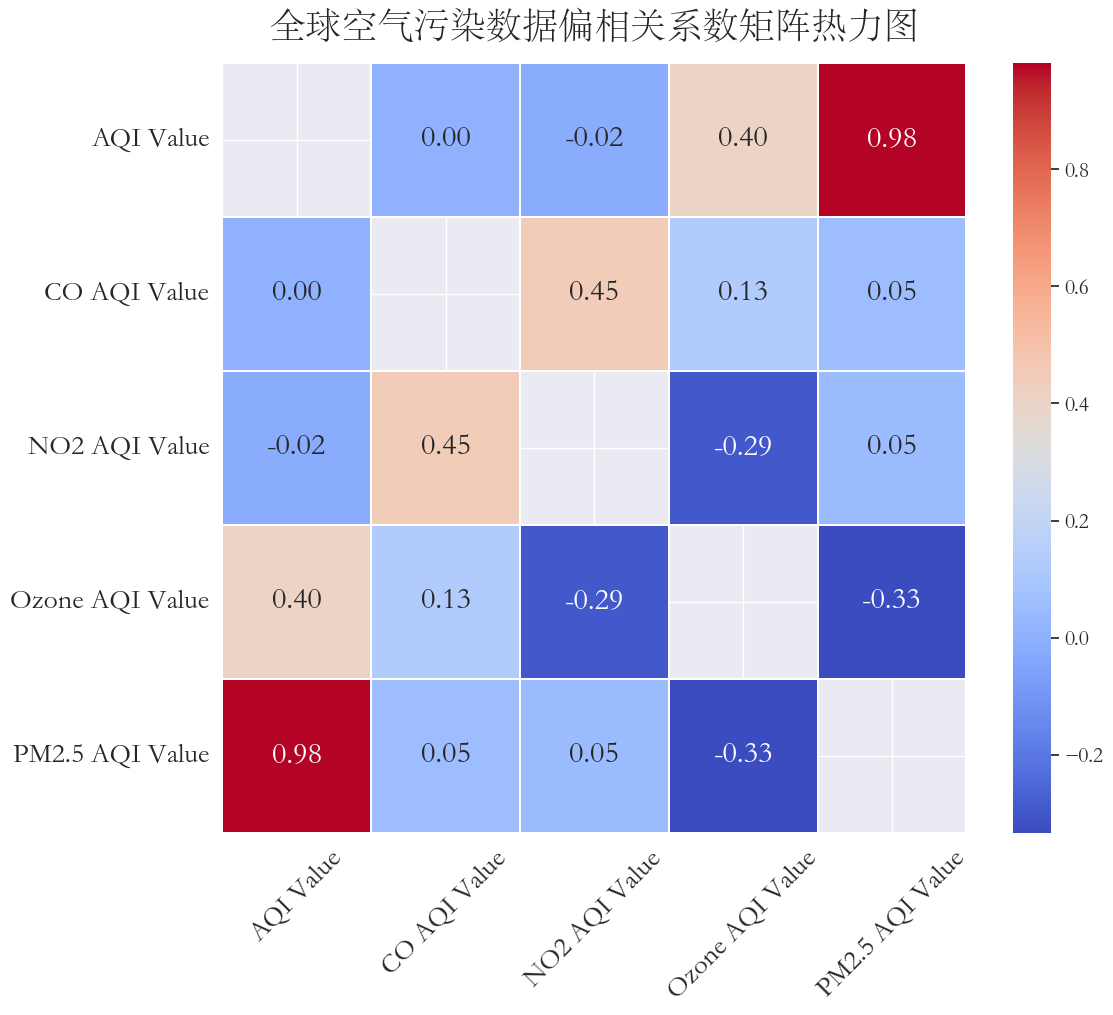

相关系数矩阵:
                 AQI Value  CO AQI Value  Ozone AQI Value  NO2 AQI Value  \
AQI Value         1.000000      0.430602         0.405310       0.231758   
CO AQI Value      0.430602      1.000000         0.145724       0.488092   
Ozone AQI Value   0.405310      0.145724         1.000000      -0.181818   
NO2 AQI Value     0.231758      0.488092        -0.181818       1.000000   
PM2.5 AQI Value   0.984327      0.438557         0.339887       0.260127   

                 PM2.5 AQI Value  
AQI Value               0.984327  
CO AQI Value            0.438557  
Ozone AQI Value         0.339887  
NO2 AQI Value           0.260127  
PM2.5 AQI Value         1.000000  


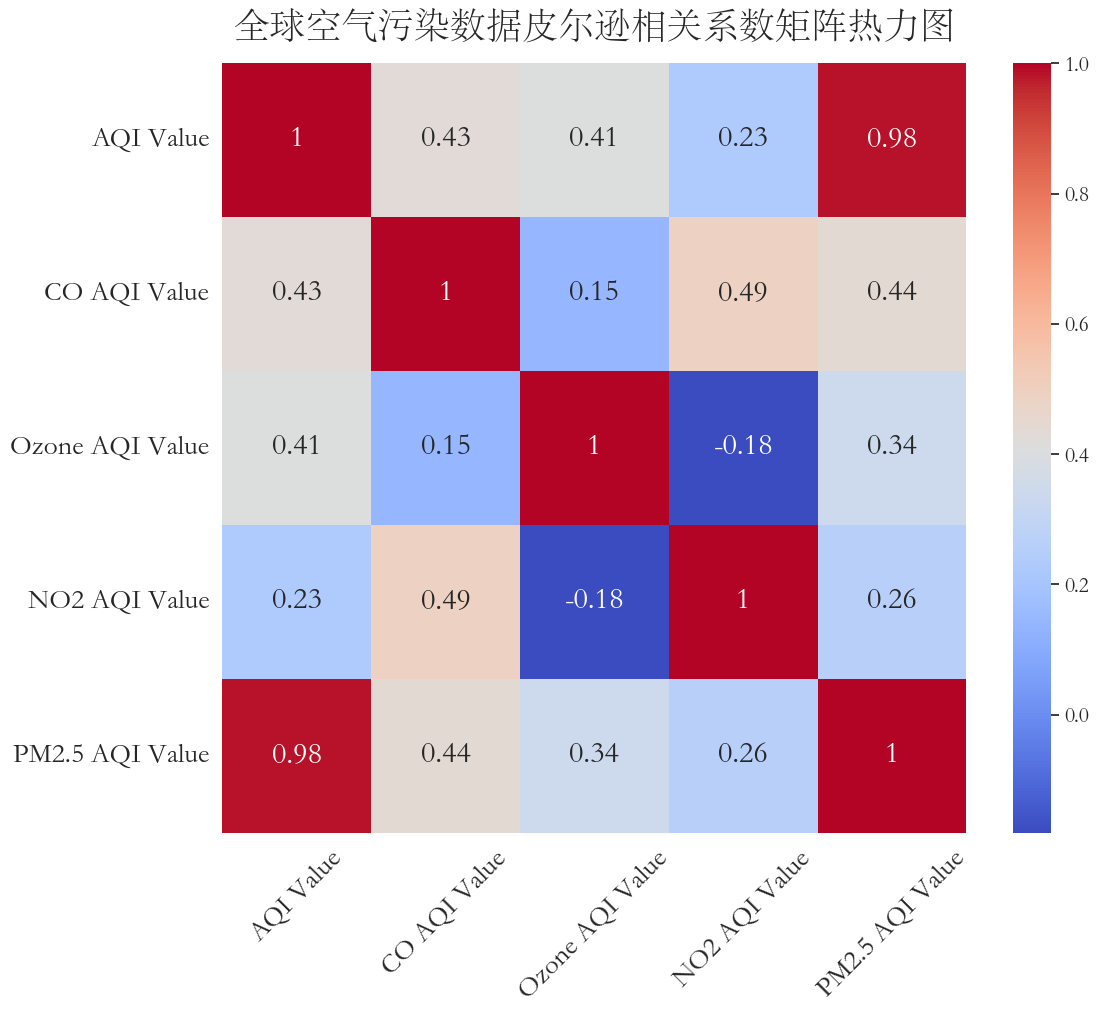

In [17]:
import pandas as pd
import numpy as np
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

# 读取数据集
data = pd.read_csv('F:/zhoumian/book/global air pollution dataset.csv')

# 选择要分析的列
columns_to_analyze = ['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']

# 缺失值处理
data = data[columns_to_analyze].dropna()

# 计算偏相关系数
partial_corr_result = pd.DataFrame({
    'Variable 1': [],
    'Variable 2': [],
    'Partial Correlation': []
})

# Calculate partial correlations
for i, var1 in enumerate(columns_to_analyze):
    for var2 in columns_to_analyze[i+1:]:
        covar = [v for v in columns_to_analyze if v != var1 and v != var2]
        r = pg.partial_corr(data=data, x=var1, y=var2, covar=covar)
        new_row = pd.DataFrame({
            'Variable 1': [var1],
            'Variable 2': [var2],
            'Partial Correlation': [r.at['pearson', 'r']]
        })
        partial_corr_result = pd.concat([partial_corr_result, new_row], ignore_index=True)

# 打印偏相关系数结果
print("偏相关系数结果:")
print(partial_corr_result)

# 转换偏相关系数结果为矩阵格式
partial_corr_matrix = partial_corr_result.pivot(index='Variable 1', columns='Variable 2', values='Partial Correlation')
partial_corr_matrix = partial_corr_matrix.combine_first(partial_corr_matrix.T)

# 绘制偏相关系数热力图
sns.set(font='STSong', font_scale=1.4)  # Increase font scale
plt.figure(figsize=(12, 10))  # Increase figure size
sns.heatmap(partial_corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.05,
            xticklabels=1, yticklabels=1, annot_kws={"size": 22})  # Increased annotation font size

plt.title('全球空气污染数据偏相关系数矩阵热力图', fontsize=26, pad=20)
plt.xticks(rotation=45, fontsize=20)
plt.yticks(rotation=0, fontsize=20)
plt.savefig('F:/zhoumian/book/偏相关系数热力图_air_pollution_data.svg', dpi=300, pad_inches=0.3, bbox_inches='tight')
plt.show()

# 计算皮尔逊相关系数矩阵
corr_matrix_subset = data.corr()

# 打印皮尔逊相关系数矩阵
print("相关系数矩阵:")
print(corr_matrix_subset)

# 可视化皮尔逊相关系数矩阵
plt.figure(figsize=(12, 10))  # Increase figure size
sns.set(font='STSong', font_scale=1.4)  # Increase font scale
sns.heatmap(corr_matrix_subset, annot=True, cmap='coolwarm', xticklabels=1, yticklabels=1,
            annot_kws={"size": 22})  # Increased annotation font size

plt.title('全球空气污染数据皮尔逊相关系数矩阵热力图', fontsize=26, pad=20)
plt.xticks(rotation=45, fontsize=20)
plt.yticks(rotation=0, fontsize=20)
plt.savefig('F:/zhoumian/book/相关性热力图_air_pollution_data.svg', dpi=300, pad_inches=0.3, bbox_inches='tight')
plt.show()


Partial Correlation Results:
        Variable 1       Variable 2  Partial Correlation
0        AQI Value     CO AQI Value             0.002808
1        AQI Value  Ozone AQI Value             0.402641
2        AQI Value    NO2 AQI Value            -0.017512
3        AQI Value  PM2.5 AQI Value             0.981044
4     CO AQI Value  Ozone AQI Value             0.130957
5     CO AQI Value    NO2 AQI Value             0.450210
6     CO AQI Value  PM2.5 AQI Value             0.054239
7  Ozone AQI Value    NO2 AQI Value            -0.293051
8  Ozone AQI Value  PM2.5 AQI Value            -0.334127
9    NO2 AQI Value  PM2.5 AQI Value             0.049084


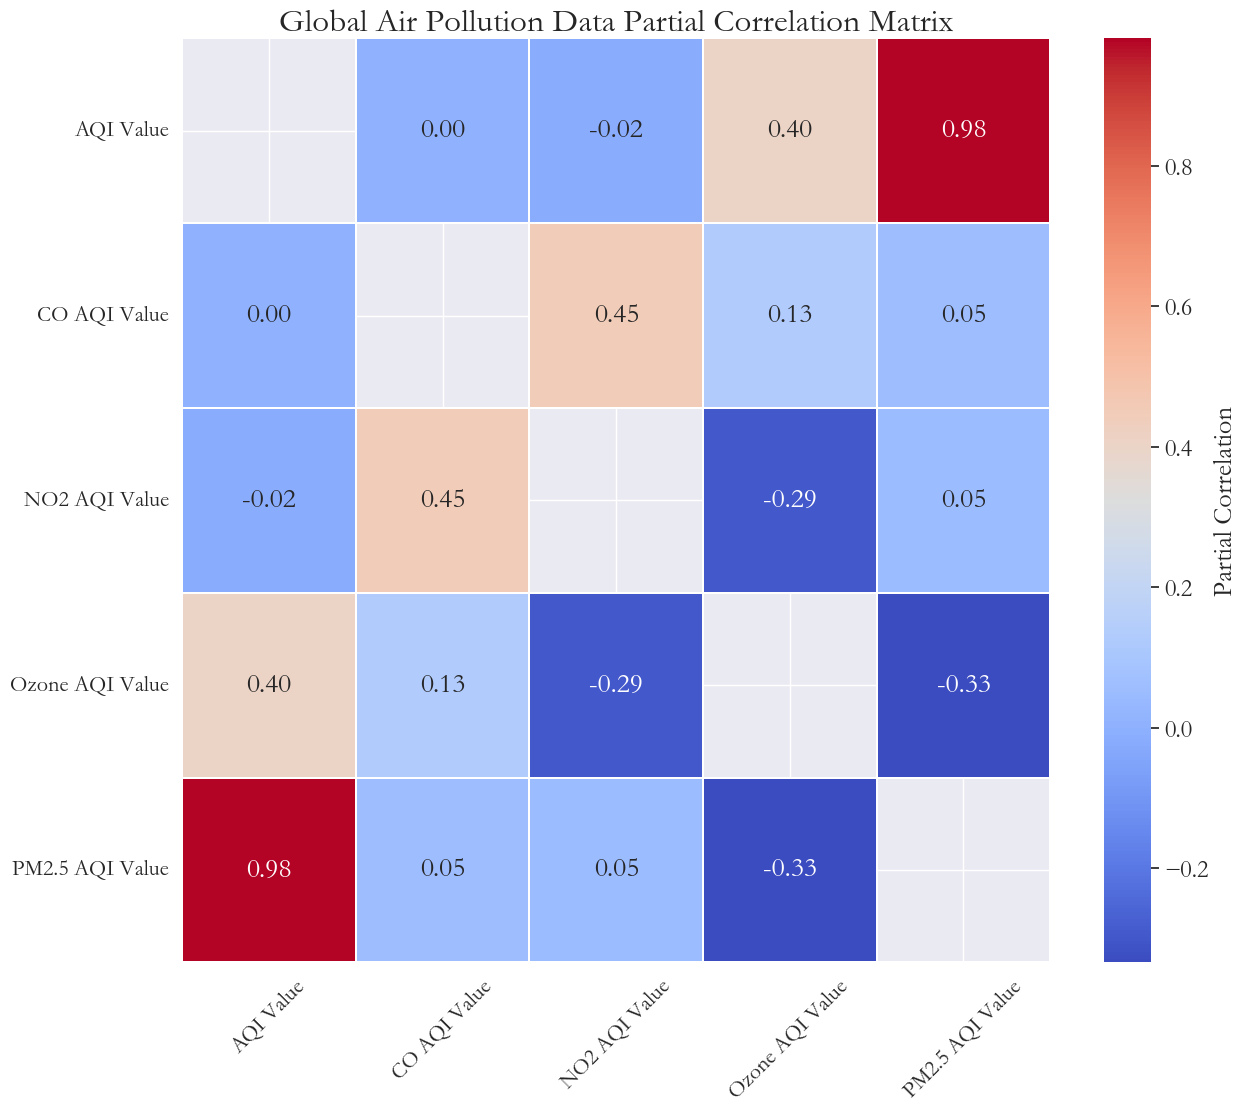

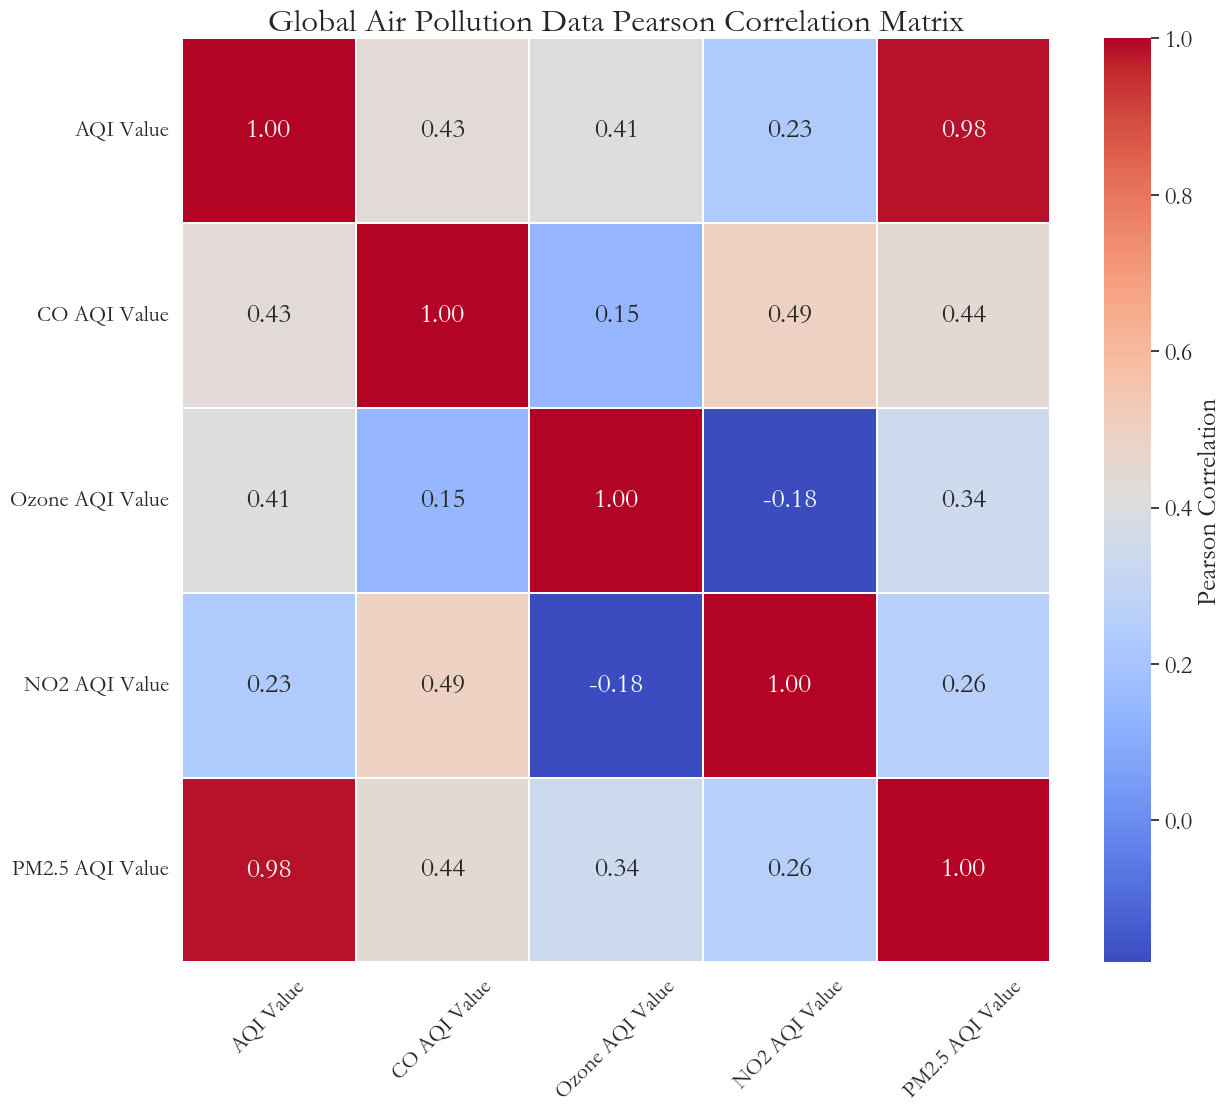

In [12]:
import pandas as pd
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('F:/zhoumian/book/global air pollution dataset.csv')

# Select columns to analyze
columns_to_analyze = ['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']

# Drop missing values for selected columns
data = data[columns_to_analyze].dropna()

# Calculate partial correlations
partial_corr_result = pd.DataFrame({
    'Variable 1': [],
    'Variable 2': [],
    'Partial Correlation': []
})

# Loop through pairs of variables and compute partial correlation
for i, var1 in enumerate(columns_to_analyze):
    for var2 in columns_to_analyze[i+1:]:
        covar = [v for v in columns_to_analyze if v != var1 and v != var2]
        r = pg.partial_corr(data=data, x=var1, y=var2, covar=covar)
        new_row = pd.DataFrame({
            'Variable 1': [var1],
            'Variable 2': [var2],
            'Partial Correlation': [r.at['pearson', 'r']]
        })
        partial_corr_result = pd.concat([partial_corr_result, new_row], ignore_index=True)

# Print partial correlation results
print("Partial Correlation Results:")
print(partial_corr_result)

# Convert partial correlation result to matrix format
partial_corr_matrix = partial_corr_result.pivot(index='Variable 1', columns='Variable 2', values='Partial Correlation')
partial_corr_matrix = partial_corr_matrix.combine_first(partial_corr_matrix.T)

# Plot the partial correlation heatmap
sns.set(font='STSong', font_scale=1.6)  # Adjust font scale for clarity
plt.figure(figsize=(14, 12))  # Increase figure size for better readability
sns.heatmap(
    partial_corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.1,
    annot_kws={"size": 20},  # Increase annotation font size
    cbar_kws={'label': 'Partial Correlation'},  # Label for color bar
    xticklabels=True, yticklabels=True
)

plt.title('Global Air Pollution Data Partial Correlation Matrix', fontsize=24)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(rotation=0, fontsize=16)
plt.savefig('F:/zhoumian/book/partial_correlation_heatmap_air_pollution_data.svg', dpi=300, bbox_inches='tight')
plt.show()

# Compute Pearson correlation matrix for comparison
pearson_corr_matrix = data.corr()

# Plot the Pearson correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    pearson_corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.1,
    annot_kws={"size": 20},  # Adjust annotation font size
    cbar_kws={'label': 'Pearson Correlation'},  # Label for color bar
    xticklabels=True, yticklabels=True
)

plt.title('Global Air Pollution Data Pearson Correlation Matrix', fontsize=24)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(rotation=0, fontsize=16)
plt.savefig('F:/zhoumian/book/pearson_correlation_heatmap_air_pollution_data.svg', dpi=300, bbox_inches='tight')
plt.show()


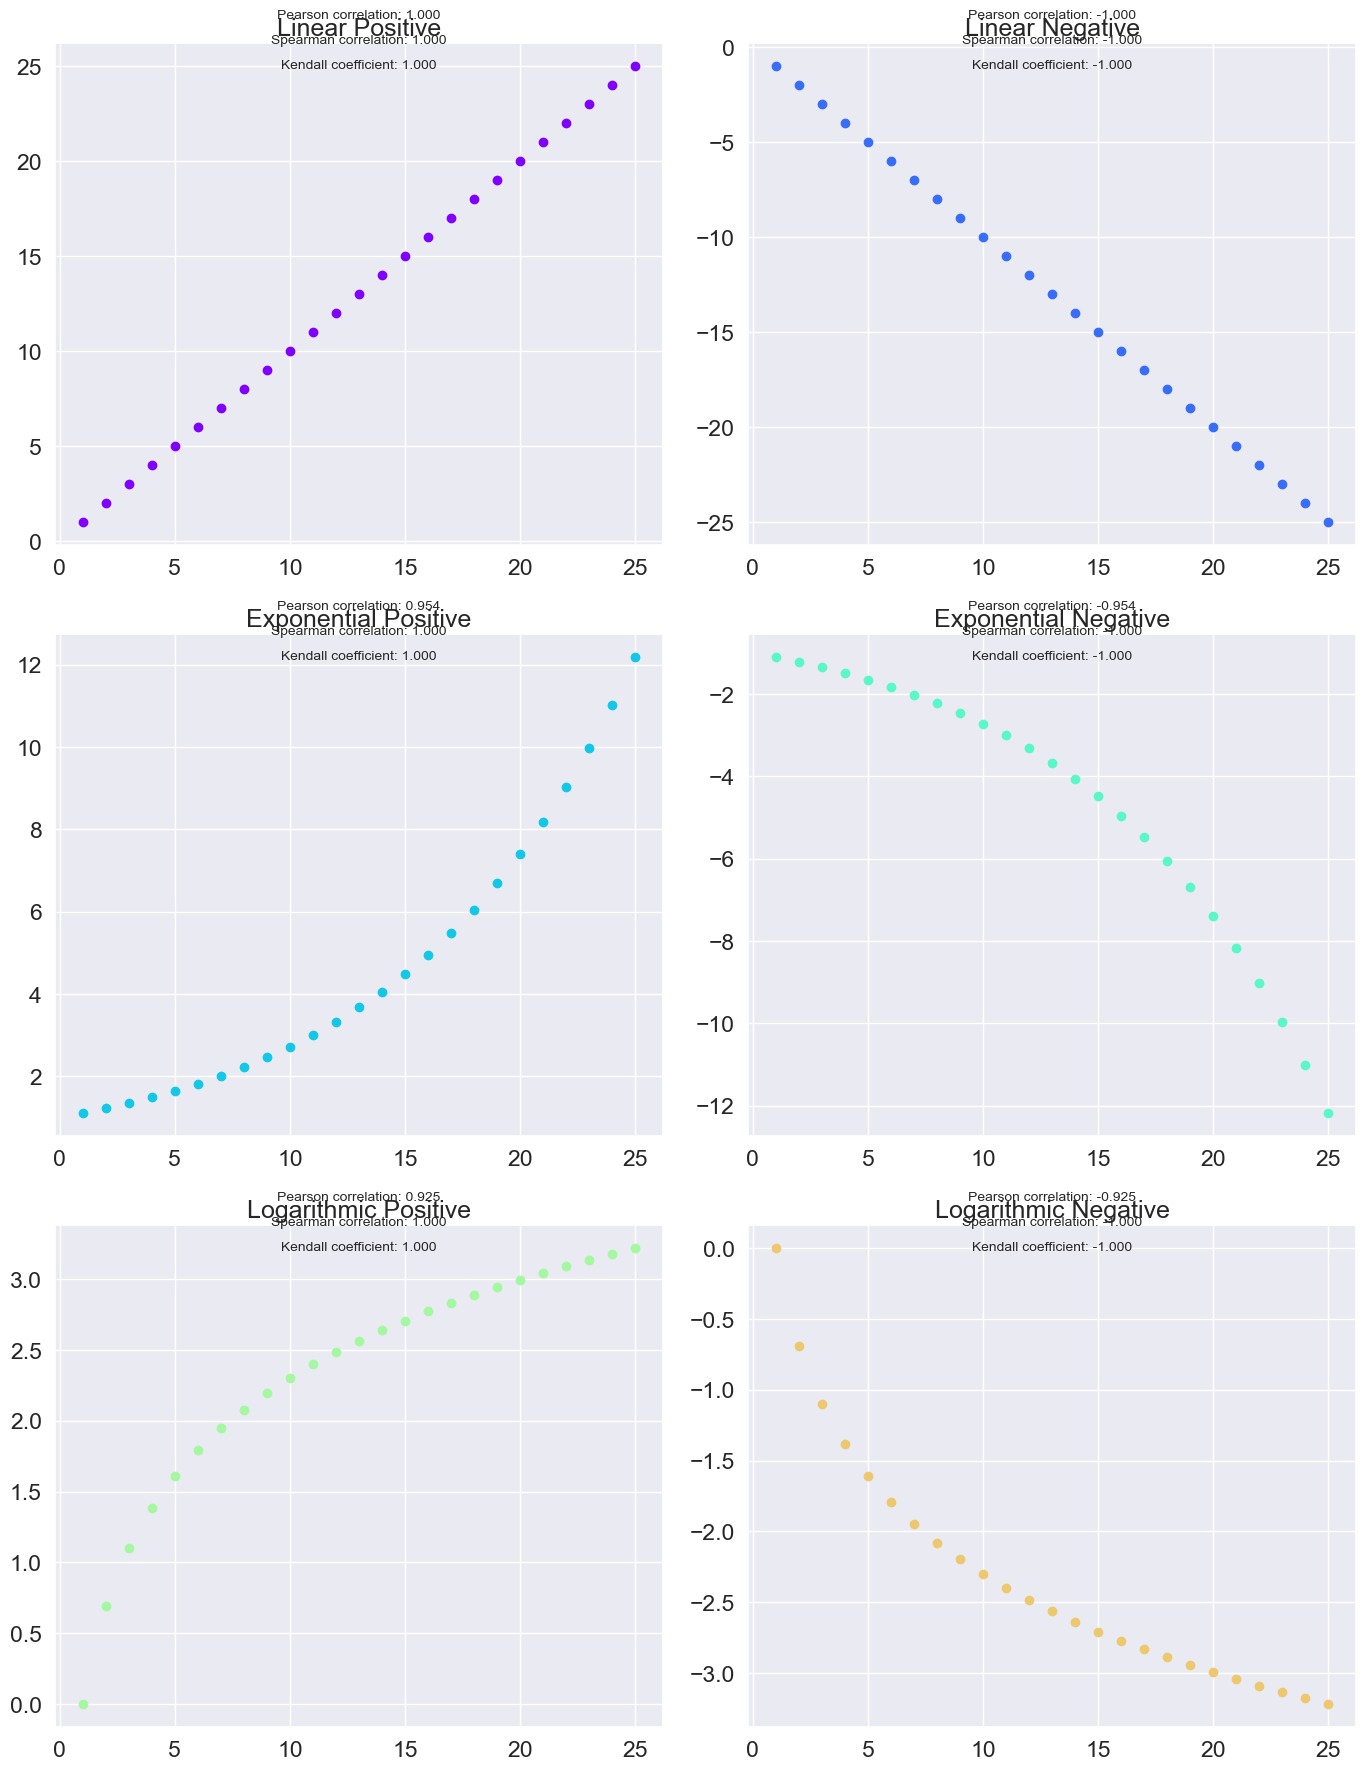

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau

# Generate sample data
np.random.seed(0)
x = np.arange(1, 26)
y_linear_positive = x
y_linear_negative = -x
y_exponential_positive = np.exp(x / 10)
y_exponential_negative = -np.exp(x / 10)
y_logarithmic_positive = np.log(x)
y_logarithmic_negative = -np.log(x)
y_parabolic_positive = x**2
y_parabolic_negative = -x**2

# Store data in a list for iteration
data = [
    (x, y_linear_positive, 'Linear Positive'),
    (x, y_linear_negative, 'Linear Negative'),
    (x, y_exponential_positive, 'Exponential Positive'),
    (x, y_exponential_negative, 'Exponential Negative'),
    (x, y_logarithmic_positive, 'Logarithmic Positive'),
    (x, y_logarithmic_negative, 'Logarithmic Negative'),
    (x, y_parabolic_positive, 'Parabolic Positive'),
    (x, y_parabolic_negative, 'Parabolic Negative')
]

# Set up the plot
fig, axs = plt.subplots(3, 2, figsize=(14, 18))
axs = axs.flatten()

colors = plt.cm.rainbow(np.linspace(0, 1, len(data)))

# Loop through each dataset and plot
for ax, (x, y, title), color in zip(axs, data, colors):
    ax.scatter(x, y, color=color)
    ax.set_title(title)
    
    # Calculate correlation coefficients
    pearson_corr, _ = pearsonr(x, y)
    spearman_corr, _ = spearmanr(x, y)
    kendall_corr, _ = kendalltau(x, y)
    
    # Add text annotations at the top
    ax.text(0.5, 1.05, f'Pearson correlation: {pearson_corr:.3f}', 
            transform=ax.transAxes, horizontalalignment='center', fontsize=10)
    ax.text(0.5, 1.00, f'Spearman correlation: {spearman_corr:.3f}', 
            transform=ax.transAxes, horizontalalignment='center', fontsize=10)
    ax.text(0.5, 0.95, f'Kendall coefficient: {kendall_corr:.3f}', 
            transform=ax.transAxes, horizontalalignment='center', fontsize=10)

plt.tight_layout()
plt.show()


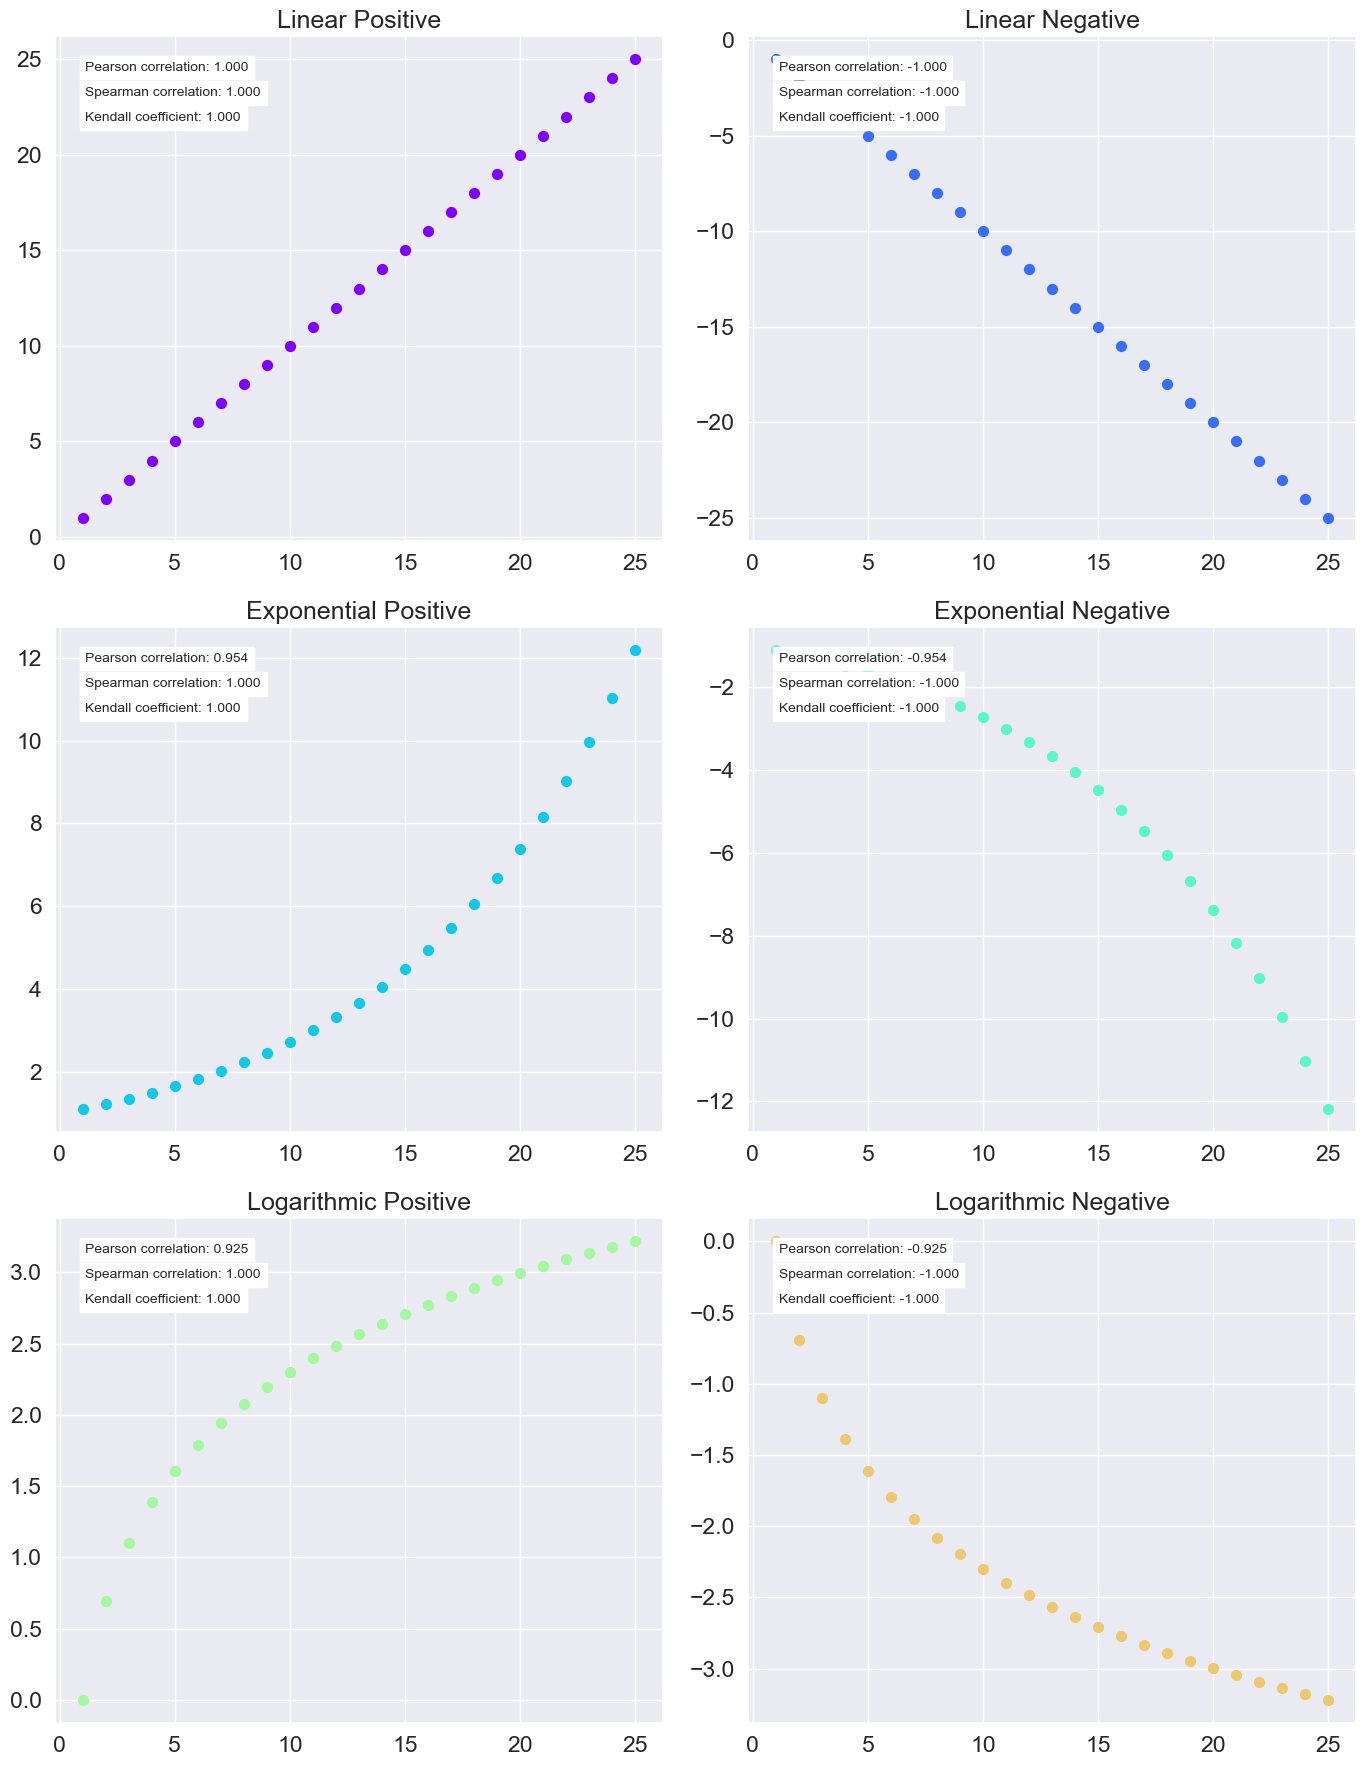

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau

# Generate sample data
np.random.seed(0)
x = np.arange(1, 26)
y_linear_positive = x
y_linear_negative = -x
y_exponential_positive = np.exp(x / 10)
y_exponential_negative = -np.exp(x / 10)
y_logarithmic_positive = np.log(x)
y_logarithmic_negative = -np.log(x)
y_parabolic_positive = x**2
y_parabolic_negative = -x**2

# Store data in a list for iteration
data = [
    (x, y_linear_positive, 'Linear Positive'),
    (x, y_linear_negative, 'Linear Negative'),
    (x, y_exponential_positive, 'Exponential Positive'),
    (x, y_exponential_negative, 'Exponential Negative'),
    (x, y_logarithmic_positive, 'Logarithmic Positive'),
    (x, y_logarithmic_negative, 'Logarithmic Negative'),
    (x, y_parabolic_positive, 'Parabolic Positive'),
    (x, y_parabolic_negative, 'Parabolic Negative')
]

# Set up the plot
fig, axs = plt.subplots(3, 2, figsize=(14, 18))
axs = axs.flatten()

colors = plt.cm.rainbow(np.linspace(0, 1, len(data)))

# Loop through each dataset and plot
for ax, (x, y, title), color in zip(axs, data, colors):
    ax.scatter(x, y, color=color, s=50)  # Thicker points
    ax.set_title(title)
    
    # Calculate correlation coefficients
    pearson_corr, _ = pearsonr(x, y)
    spearman_corr, _ = spearmanr(x, y)
    kendall_corr, _ = kendalltau(x, y)
    
    # Add text annotations at the top left
    ax.text(0.05, 0.95, f'Pearson correlation: {pearson_corr:.3f}', 
            transform=ax.transAxes, verticalalignment='top', fontsize=10, backgroundcolor='white')
    ax.text(0.05, 0.90, f'Spearman correlation: {spearman_corr:.3f}', 
            transform=ax.transAxes, verticalalignment='top', fontsize=10, backgroundcolor='white')
    ax.text(0.05, 0.85, f'Kendall coefficient: {kendall_corr:.3f}', 
            transform=ax.transAxes, verticalalignment='top', fontsize=10, backgroundcolor='white')

plt.tight_layout()
plt.show()


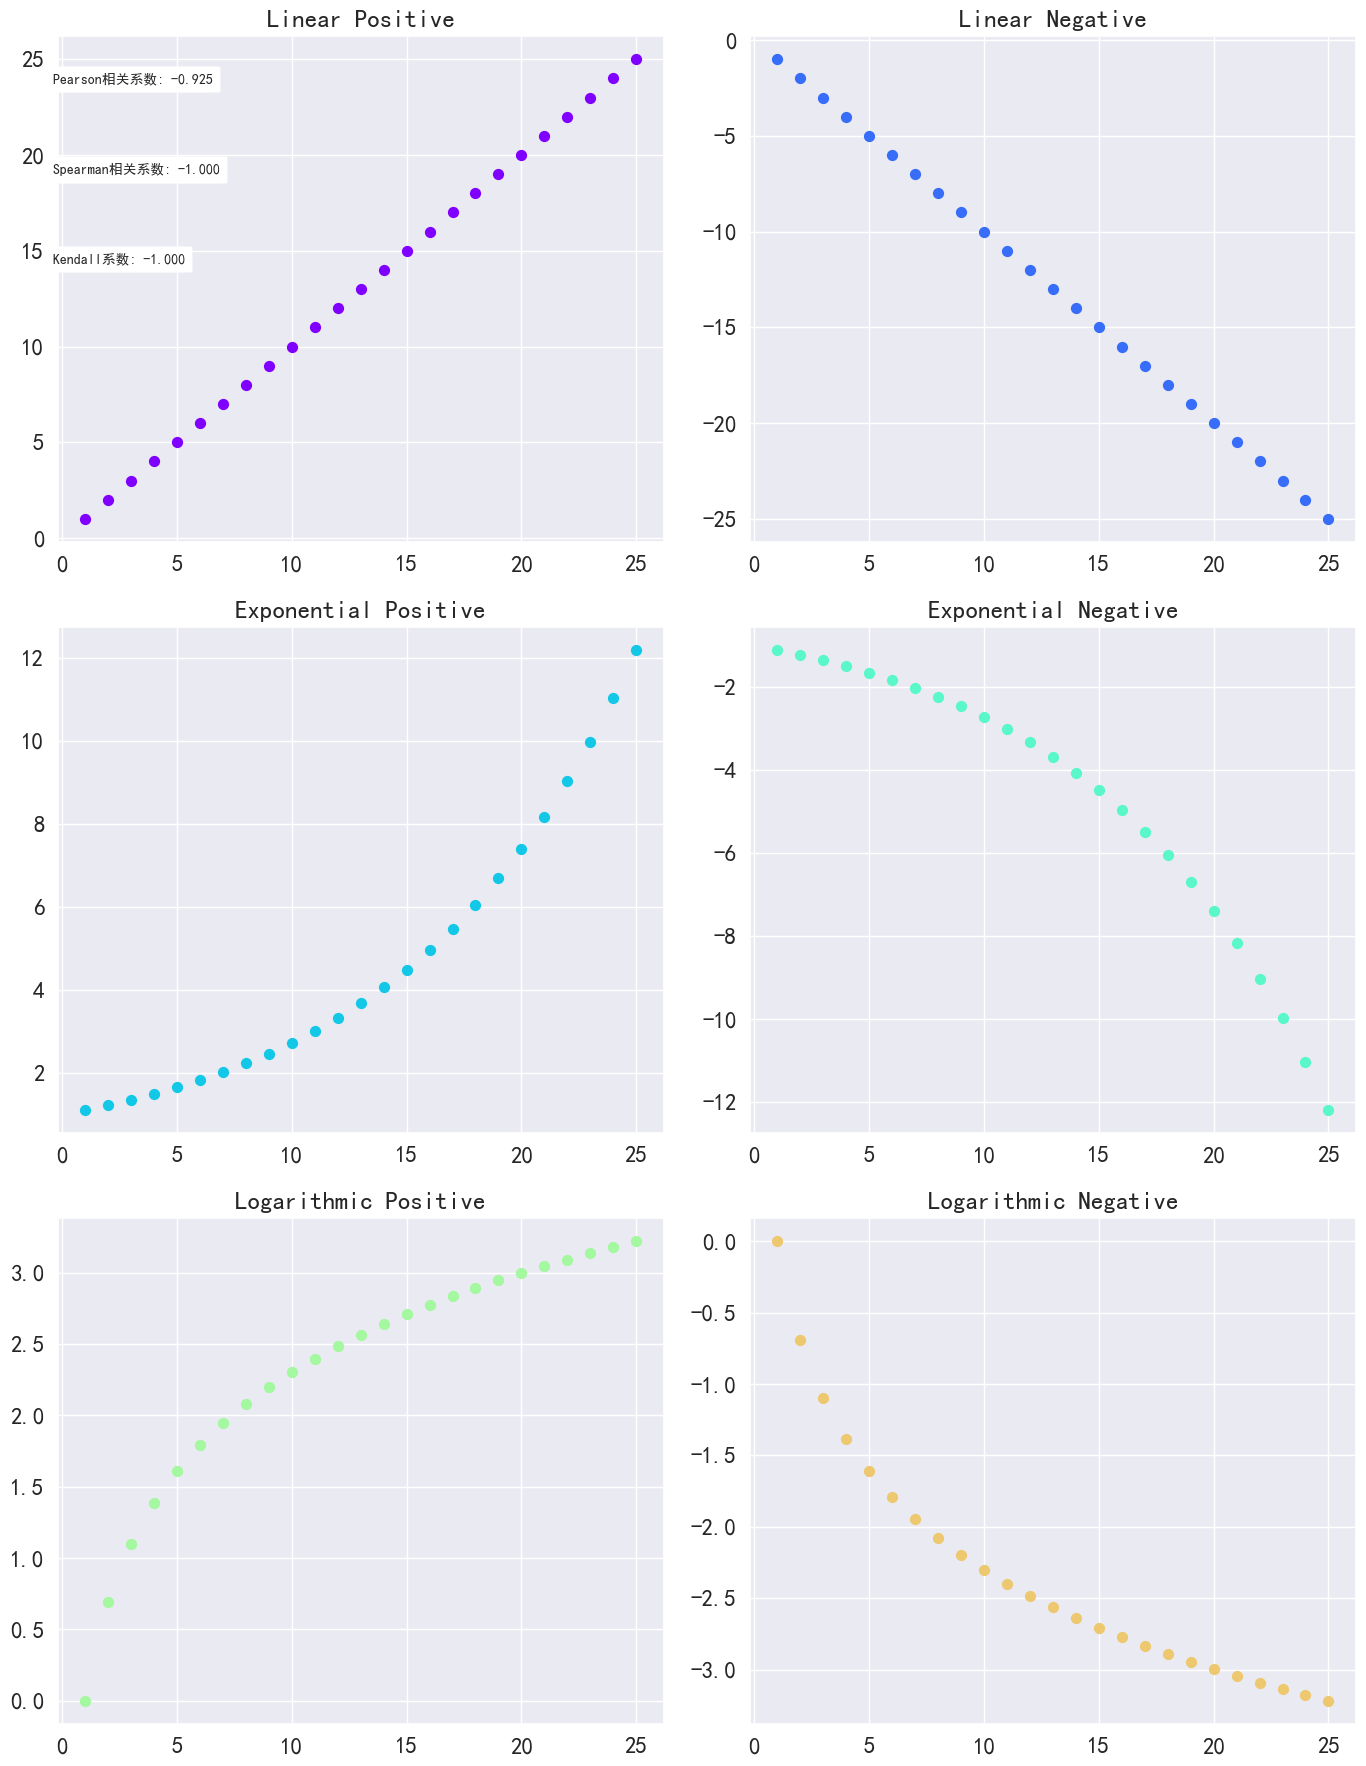

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau
from matplotlib.font_manager import FontProperties

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# Generate sample data
np.random.seed(0)
x = np.arange(1, 26)
y_linear_positive = x
y_linear_negative = -x
y_exponential_positive = np.exp(x / 10)
y_exponential_negative = -np.exp(x / 10)
y_logarithmic_positive = np.log(x)
y_logarithmic_negative = -np.log(x)
y_parabolic_positive = x**2
y_parabolic_negative = -x**2

# Store data in a list for iteration
data = [
    (x, y_linear_positive, 'Linear Positive'),
    (x, y_linear_negative, 'Linear Negative'),
    (x, y_exponential_positive, 'Exponential Positive'),
    (x, y_exponential_negative, 'Exponential Negative'),
    (x, y_logarithmic_positive, 'Logarithmic Positive'),
    (x, y_logarithmic_negative, 'Logarithmic Negative'),
    (x, y_parabolic_positive, 'Parabolic Positive'),
    (x, y_parabolic_negative, 'Parabolic Negative')
]

# 设置图表
fig, axs = plt.subplots(3, 2, figsize=(14, 18))
axs = axs.flatten()

colors = plt.cm.rainbow(np.linspace(0, 1, len(data)))

# 循环遍历每个数据集并绘制
for ax, (x, y, title), color in zip(axs, data, colors):
    ax.scatter(x, y, color=color, s=50)  # 较粗的点
    ax.set_title(title)
    
    # 计算相关系数
    pearson_corr, _ = pearsonr(x, y)
    spearman_corr, _ = spearmanr(x, y)
    kendall_corr, _ = kendalltau(x, y)
    
    # 在图形外部左上方添加文本注释
    fig.text(0.05, 0.95, f'Pearson相关系数: {pearson_corr:.3f}', 
             fontsize=10, verticalalignment='top', backgroundcolor='white', fontproperties=FontProperties('SimHei'))
    fig.text(0.05, 0.90, f'Spearman相关系数: {spearman_corr:.3f}', 
             fontsize=10, verticalalignment='top', backgroundcolor='white', fontproperties=FontProperties('SimHei'))
    fig.text(0.05, 0.85, f'Kendall系数: {kendall_corr:.3f}', 
             fontsize=10, verticalalignment='top', backgroundcolor='white', fontproperties=FontProperties('SimHei'))

# 调整布局
plt.tight_layout()
# 显示图表
plt.show()

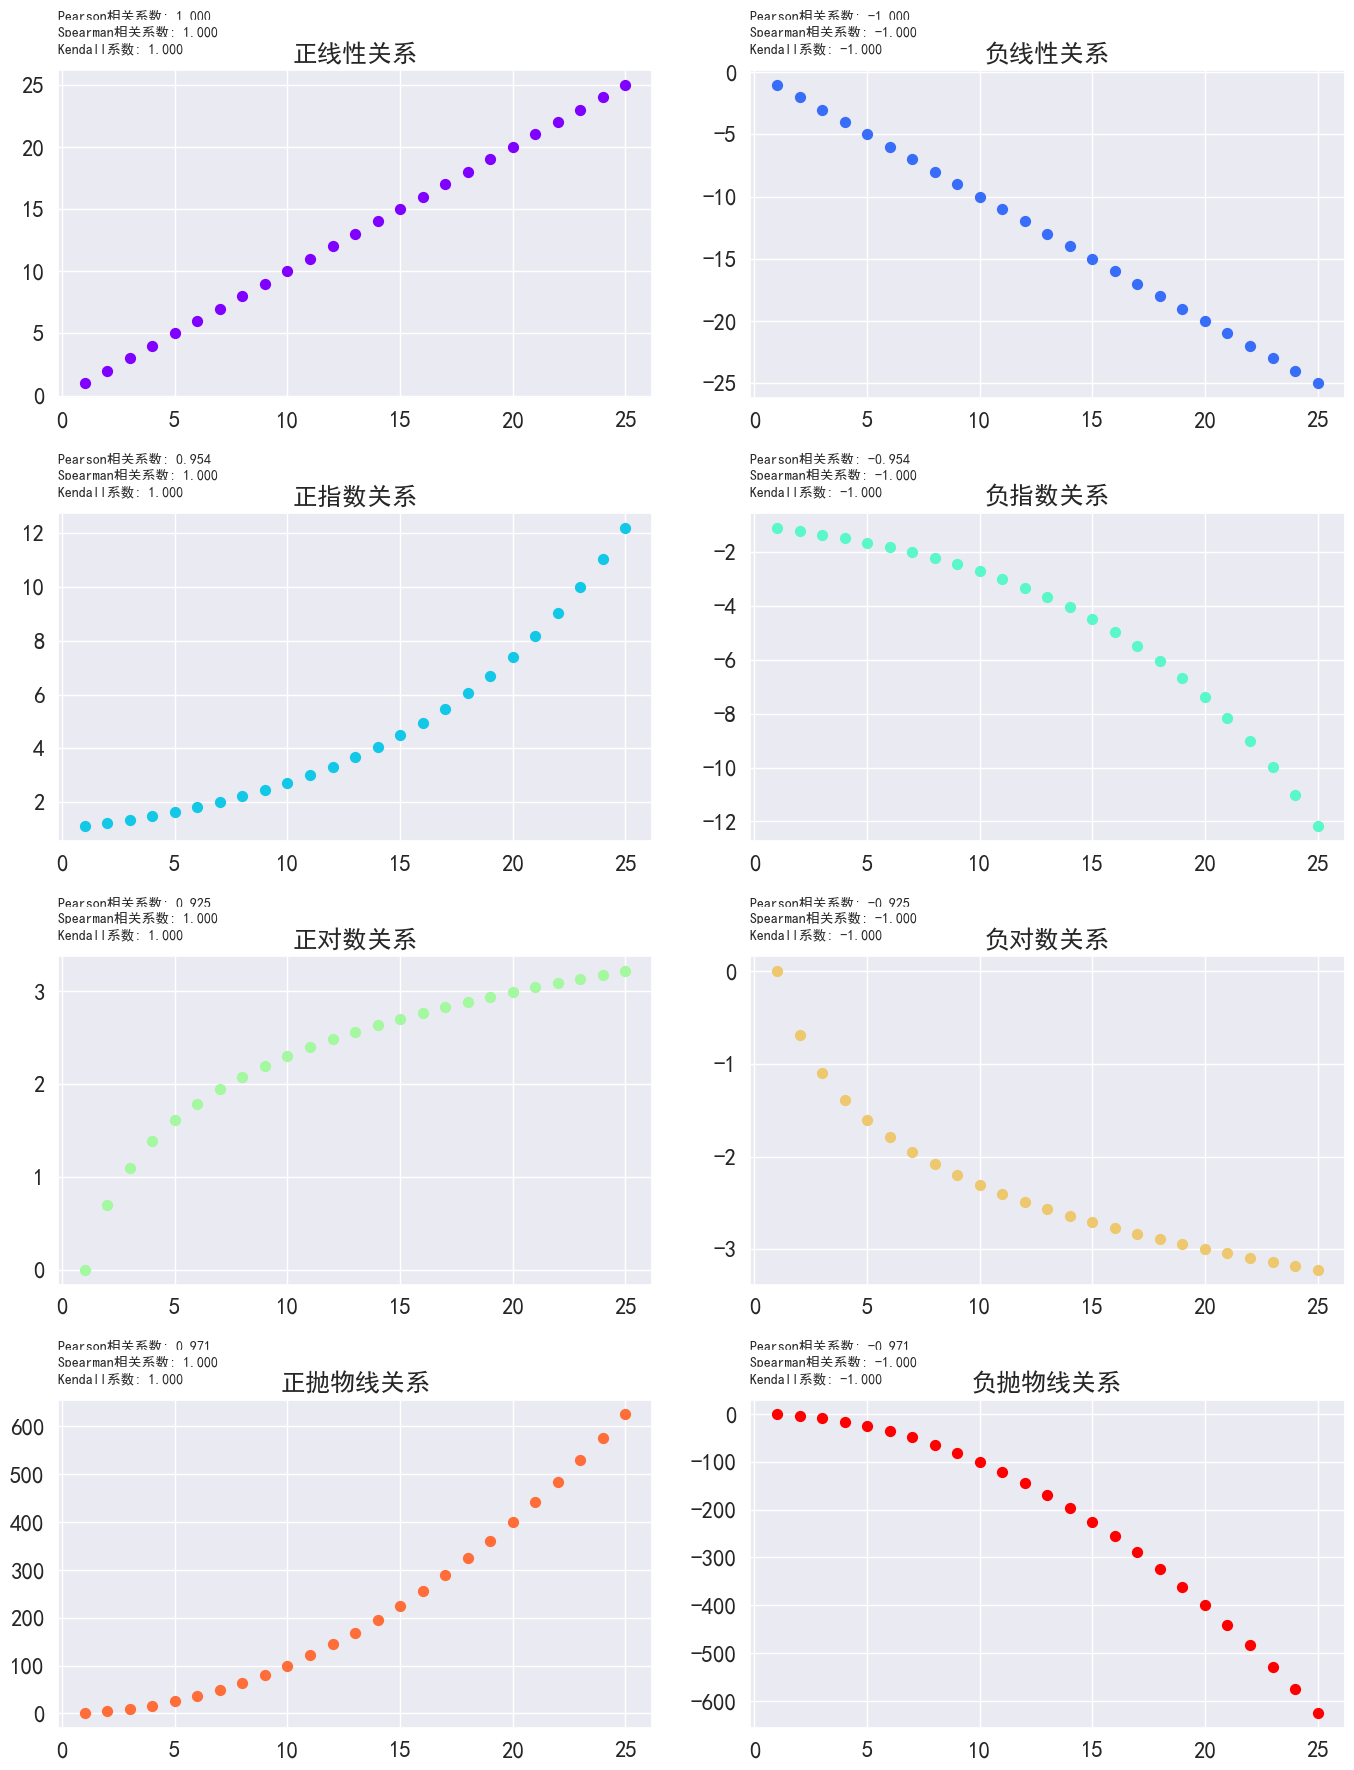

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau

# Generate sample data
np.random.seed(0)
x = np.arange(1, 26)
y_linear_positive = x
y_linear_negative = -x
y_exponential_positive = np.exp(x / 10)
y_exponential_negative = -np.exp(x / 10)
y_logarithmic_positive = np.log(x)
y_logarithmic_negative = -np.log(x)
y_parabolic_positive = x**2
y_parabolic_negative = -x**2

# Store data in a list for iteration
data = [
    (x, y_linear_positive, '正线性关系'),
    (x, y_linear_negative, '负线性关系'),
    (x, y_exponential_positive, '正指数关系'),
    (x, y_exponential_negative, '负指数关系'),
    (x, y_logarithmic_positive, '正对数关系'),
    (x, y_logarithmic_negative, '负对数关系'),
    (x, y_parabolic_positive, '正抛物线关系'),
    (x, y_parabolic_negative, '负抛物线关系')
]

# Set up the plot
fig, axs = plt.subplots(4, 2, figsize=(14, 18))
axs = axs.flatten()

colors = plt.cm.rainbow(np.linspace(0, 1, len(data)))

# Loop through each dataset and plot
for i, ((x, y, title), color) in enumerate(zip(data, colors)):
    ax = axs[i]
    ax.scatter(x, y, color=color, s=50)  # Thicker points
    ax.set_title(title)
    
    # Calculate correlation coefficients
    pearson_corr, _ = pearsonr(x, y)
    spearman_corr, _ = spearmanr(x, y)
    kendall_corr, _ = kendalltau(x, y)
    
    # Add text annotations outside the plot area
    ax.annotate(f'Pearson相关系数: {pearson_corr:.3f}', xy=(0, 1.15), xycoords='axes fraction', fontsize=10, backgroundcolor='white')
    ax.annotate(f'Spearman相关系数: {spearman_corr:.3f}', xy=(0, 1.10), xycoords='axes fraction', fontsize=10, backgroundcolor='white')
    ax.annotate(f'Kendall系数: {kendall_corr:.3f}', xy=(0, 1.05), xycoords='axes fraction', fontsize=10, backgroundcolor='white')

plt.tight_layout()
plt.show()


Spearman秩相关系数: 0.011936073858989812
Kendall等级相关系数: 0.00781417028883265


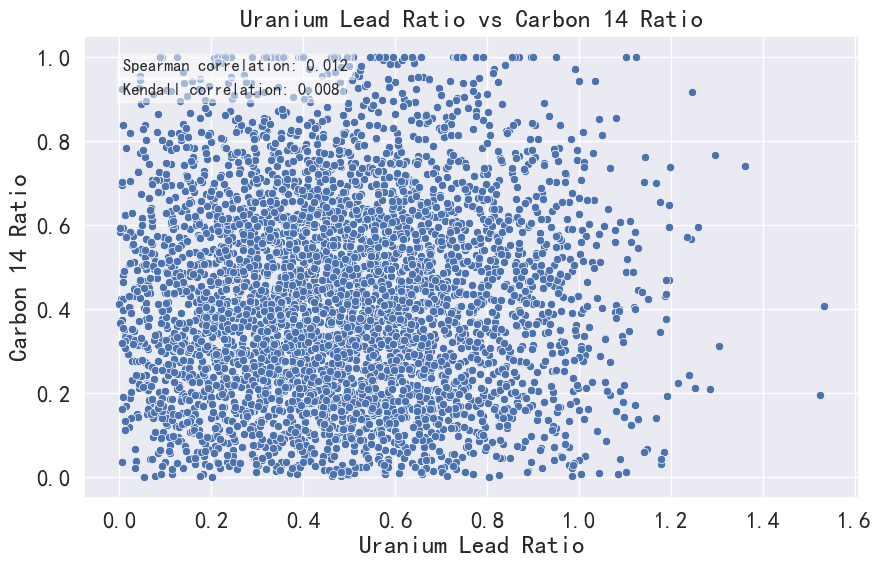

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau

# 读取数据集
data = pd.read_csv('F:/zhoumian/train_data.csv')

# 选择要分析的列
columns_to_analyze = ['uranium_lead_ratio', 'carbon_14_ratio']

# 缺失值处理
data = data[columns_to_analyze].dropna()

# 计算Spearman秩相关系数和Kendall等级相关系数
spearman_corr, spearman_pval = spearmanr(data['uranium_lead_ratio'], data['carbon_14_ratio'])
kendall_corr, kendall_pval = kendalltau(data['uranium_lead_ratio'], data['carbon_14_ratio'])

# 打印相关系数
print("Spearman秩相关系数:", spearman_corr)
print("Kendall等级相关系数:", kendall_corr)

# 绘制散点图
plt.figure(figsize=(10, 6))
sns.scatterplot(x='uranium_lead_ratio', y='carbon_14_ratio', data=data)
plt.title('Uranium Lead Ratio vs Carbon 14 Ratio')
plt.xlabel('Uranium Lead Ratio')
plt.ylabel('Carbon 14 Ratio')
plt.grid(True)
plt.text(0.05, 0.95, f'Spearman correlation: {spearman_corr:.3f}', transform=plt.gca().transAxes, verticalalignment='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.text(0.05, 0.90, f'Kendall correlation: {kendall_corr:.3f}', transform=plt.gca().transAxes, verticalalignment='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.show()


In [29]:
import pandas as pd

# 读取数据集
data = pd.read_csv('F:/zhoumian/FuelEconomy.csv')

# 打印数据框的列名
print(data.columns)


Index(['Horse Power', 'Fuel Economy (MPG)'], dtype='object')


Spearman秩相关系数: -0.9504830483048303
Kendall等级相关系数: -0.8084848484848487


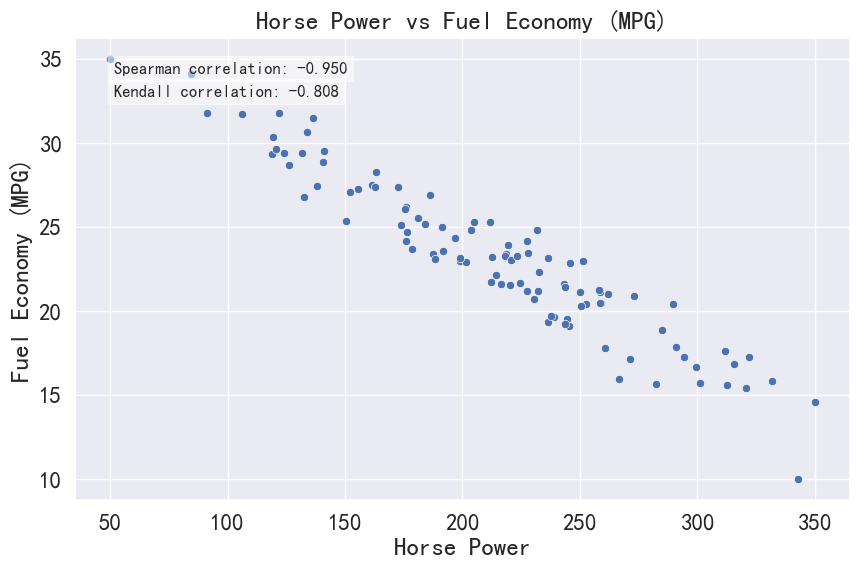

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau

# 读取数据集
data = pd.read_csv('F:/zhoumian/FuelEconomy.csv')

# 确认列名后更新要分析的列名
columns_to_analyze = ['Horse Power', 'Fuel Economy (MPG)']

# 缺失值处理
data = data[columns_to_analyze].dropna()

# 计算Spearman秩相关系数和Kendall等级相关系数
spearman_corr, spearman_pval = spearmanr(data['Horse Power'], data['Fuel Economy (MPG)'])
kendall_corr, kendall_pval = kendalltau(data['Horse Power'], data['Fuel Economy (MPG)'])

# 打印相关系数
print("Spearman秩相关系数:", spearman_corr)
print("Kendall等级相关系数:", kendall_corr)

# 绘制散点图
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Horse Power', y='Fuel Economy (MPG)', data=data)
plt.title('Horse Power vs Fuel Economy (MPG)')
plt.xlabel('Horse Power')
plt.ylabel('Fuel Economy (MPG)')
plt.grid(True)
plt.text(0.05, 0.95, f'Spearman correlation: {spearman_corr:.3f}', transform=plt.gca().transAxes, verticalalignment='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.text(0.05, 0.90, f'Kendall correlation: {kendall_corr:.3f}', transform=plt.gca().transAxes, verticalalignment='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.show()


Spearman秩相关系数: -0.9504830483048303
Kendall等级相关系数: -0.8084848484848487
Pearson相关系数: -0.9536978230405159


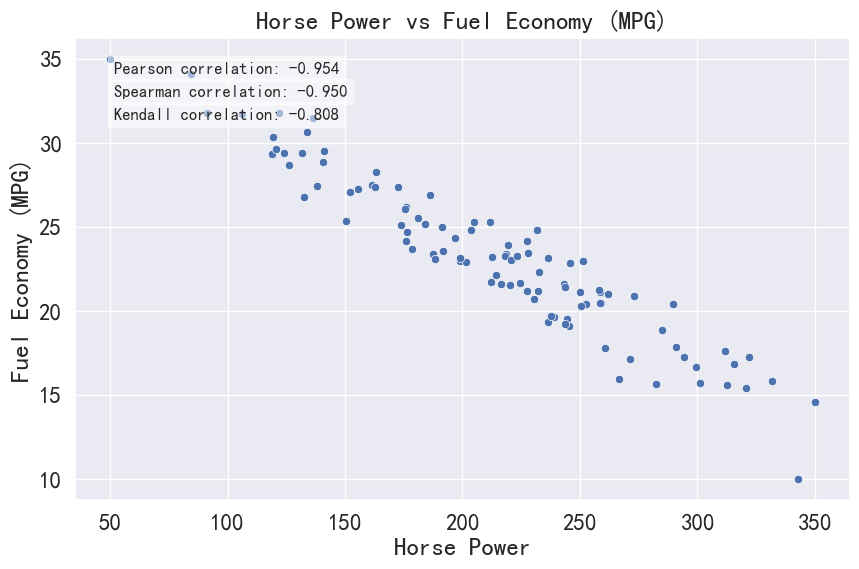

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau, pearsonr

# 读取数据集
data = pd.read_csv('F:/zhoumian/FuelEconomy.csv')

# 确认列名后更新要分析的列名
columns_to_analyze = ['Horse Power', 'Fuel Economy (MPG)']

# 缺失值处理
data = data[columns_to_analyze].dropna()

# 计算Spearman秩相关系数和Kendall等级相关系数
spearman_corr, spearman_pval = spearmanr(data['Horse Power'], data['Fuel Economy (MPG)'])
kendall_corr, kendall_pval = kendalltau(data['Horse Power'], data['Fuel Economy (MPG)'])
pearson_corr, pearson_pval = pearsonr(data['Horse Power'], data['Fuel Economy (MPG)'])

# 打印相关系数
print("Spearman秩相关系数:", spearman_corr)
print("Kendall等级相关系数:", kendall_corr)
print("Pearson相关系数:", pearson_corr)

# 绘制散点图
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Horse Power', y='Fuel Economy (MPG)', data=data)
plt.title('Horse Power vs Fuel Economy (MPG)')
plt.xlabel('Horse Power')
plt.ylabel('Fuel Economy (MPG)')
plt.grid(True)
plt.text(0.05, 0.95, f'Pearson correlation: {pearson_corr:.3f}', transform=plt.gca().transAxes, verticalalignment='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.text(0.05, 0.90, f'Spearman correlation: {spearman_corr:.3f}', transform=plt.gca().transAxes, verticalalignment='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.text(0.05, 0.85, f'Kendall correlation: {kendall_corr:.3f}', transform=plt.gca().transAxes, verticalalignment='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.show()


Pearson相关系数: -0.9536978230405159
Spearman秩相关系数: -0.9504830483048303
Kendall等级相关系数: -0.8084848484848487


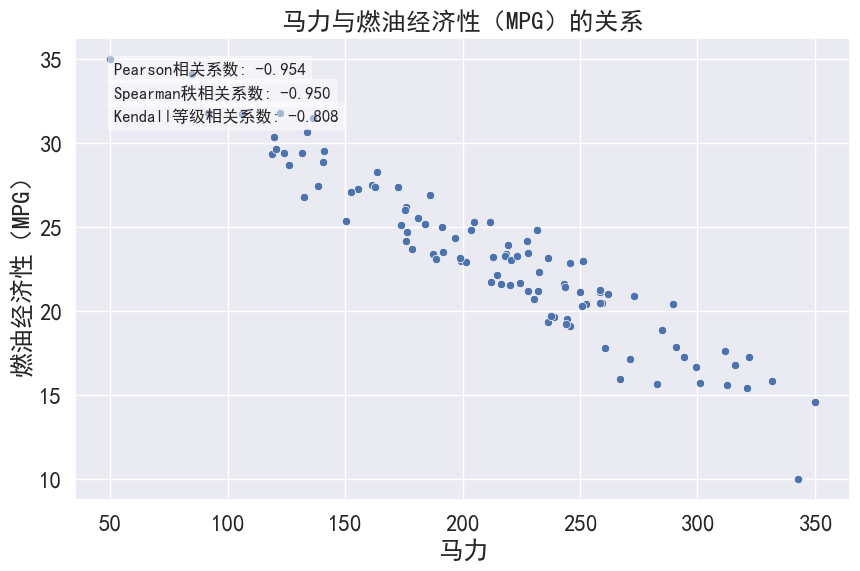

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau, pearsonr

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据集
data = pd.read_csv('F:/zhoumian/FuelEconomy.csv')
columns_to_analyze = ['Horse Power', 'Fuel Economy (MPG)']# 确认列名后更新要分析的列名
data = data[columns_to_analyze].dropna()# 缺失值处理

# 计算相关系数
spearman_corr, spearman_pval = spearmanr(data['Horse Power'], data['Fuel Economy (MPG)'])
kendall_corr, kendall_pval = kendalltau(data['Horse Power'], data['Fuel Economy (MPG)'])
pearson_corr, pearson_pval = pearsonr(data['Horse Power'], data['Fuel Economy (MPG)'])
print("Pearson相关系数:", pearson_corr)# 打印相关系数
print("Spearman秩相关系数:", spearman_corr)
print("Kendall等级相关系数:", kendall_corr)

# 绘制散点图
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Horse Power', y='Fuel Economy (MPG)', data=data)
plt.title('马力与燃油经济性（MPG）的关系')
plt.xlabel('马力')
plt.ylabel('燃油经济性（MPG）')
plt.grid(True)
plt.text(0.05, 0.95, f'Pearson相关系数: {pearson_corr:.3f}', transform=plt.gca().transAxes, verticalalignment='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.text(0.05, 0.90, f'Spearman秩相关系数: {spearman_corr:.3f}', transform=plt.gca().transAxes, verticalalignment='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.text(0.05, 0.85, f'Kendall等级相关系数: {kendall_corr:.3f}', transform=plt.gca().transAxes, verticalalignment='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.show()

Pearson相关系数: -0.25731943016016373
Spearman相关系数: -0.25002541002541
Kendall相关系数: -0.16656656656656657
互信息: 1.964636783401498


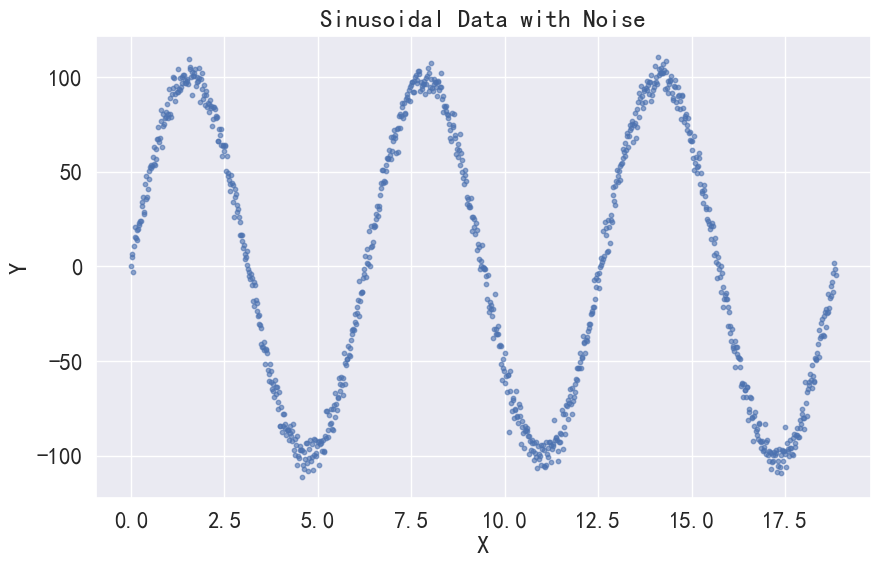

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.feature_selection import mutual_info_regression

# 生成正弦波数据
num_points = 1000
noise_factor = 5  # 噪音因子
x = np.linspace(0, 6 * np.pi, num_points)
y_wave = 100 * np.sin(x)
noise = np.random.normal(0, noise_factor, num_points)
y = y_wave + noise

# 计算相关系数和互信息
pearson_corr, _ = pearsonr(x, y)
spearman_corr, _ = spearmanr(x, y)
kendall_corr, _ = kendalltau(x, y)
mutual_info = mutual_info_regression(x.reshape(-1, 1), y)[0]

# 打印结果
print("Pearson相关系数:", pearson_corr)
print("Spearman相关系数:", spearman_corr)
print("Kendall相关系数:", kendall_corr)
print("互信息:", mutual_info)

# 可视化数据
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, s=10)
plt.title('Sinusoidal Data with Noise')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)


plt.show()


Pearson相关系数: 0.0005366127683378314
Spearman相关系数: 0.0021086421086421087
Kendall相关系数: 0.0021981981981981985
互信息: 1.589331352398585


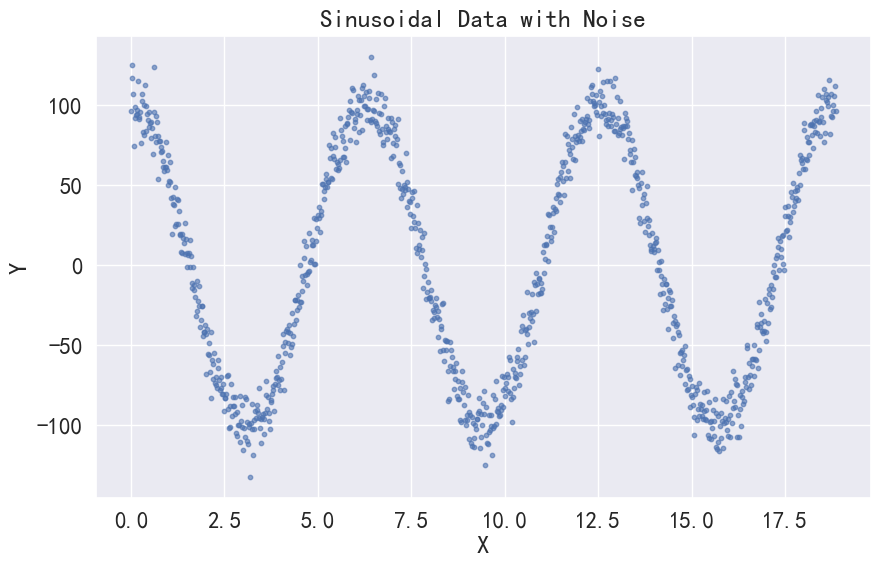

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.feature_selection import mutual_info_regression

# 生成正弦波数据
num_points = 1000
noise_factor = 10  # 噪音因子
x = np.linspace(0, 6 * np.pi, num_points)
y_wave = 100 * np.cos(x)
noise = np.random.normal(0, noise_factor, num_points)
y = y_wave + noise

# 计算相关系数和互信息
pearson_corr, _ = pearsonr(x, y)
spearman_corr, _ = spearmanr(x, y)
kendall_corr, _ = kendalltau(x, y)
mutual_info = mutual_info_regression(x.reshape(-1, 1), y)[0]

# 打印结果
print("Pearson相关系数:", pearson_corr)
print("Spearman相关系数:", spearman_corr)
print("Kendall相关系数:", kendall_corr)
print("互信息:", mutual_info)

# 可视化数据
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, s=10)
plt.title('Sinusoidal Data with Noise')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)


plt.show()

Pearson相关系数: 0.007307488313158117
Spearman相关系数: 0.00898906498906499
Kendall相关系数: 0.00625025025025025
互信息: 1.651595100614296


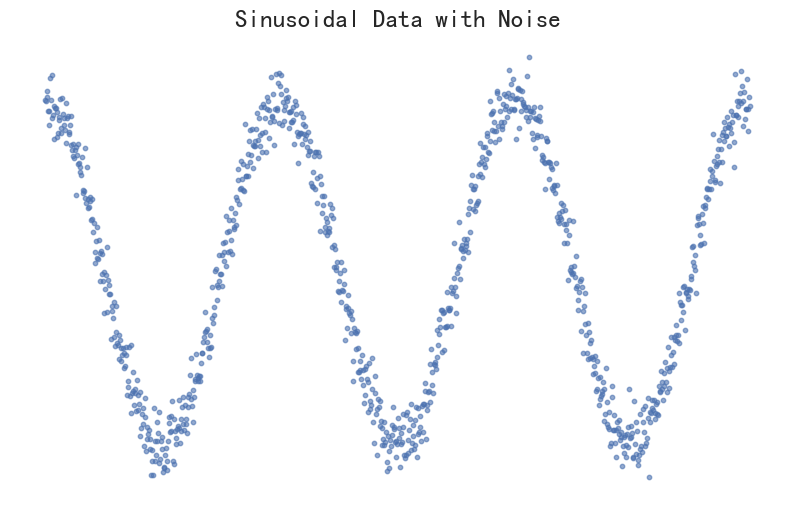

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.feature_selection import mutual_info_regression

# 设置matplotlib的背景颜色为白色
plt.rcParams['axes.facecolor'] = 'white'

# 生成正弦波数据
num_points = 1000
noise_factor = 10  # 噪音因子
x = np.linspace(0, 6 * np.pi, num_points)
y_wave = 100 * np.cos(x)
noise = np.random.normal(0, noise_factor, num_points)
y = y_wave + noise

# 计算相关系数和互信息
pearson_corr, _ = pearsonr(x, y)
spearman_corr, _ = spearmanr(x, y)
kendall_corr, _ = kendalltau(x, y)
mutual_info = mutual_info_regression(x.reshape(-1, 1), y)[0]

# 打印结果
print("Pearson相关系数:", pearson_corr)
print("Spearman相关系数:", spearman_corr)
print("Kendall相关系数:", kendall_corr)
print("互信息:", mutual_info)

# 可视化数据
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, s=10)
plt.title('Sinusoidal Data with Noise')

# 隐藏x轴和y轴
plt.axis('off')

# 显示图形
plt.show()

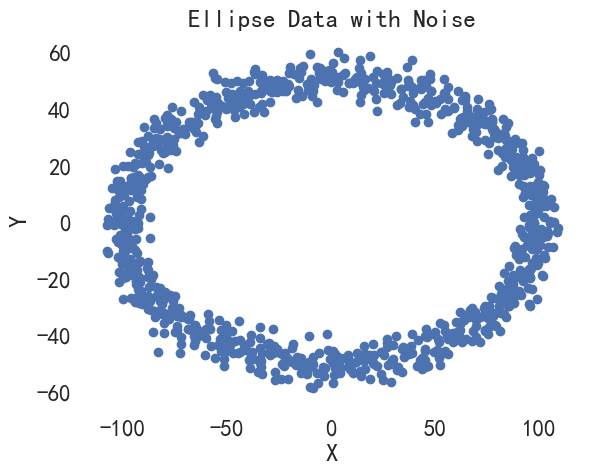

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 批量生成显著程度不同的椭圆数据，并按要求存入CSV
data_new = pd.DataFrame(columns=['new_col1', 'new_col2'])
new_col1 = []
new_col2 = []

for noise_factor in range(4, 130, 1):  # 噪音
    num_points = 1000
    # 生成椭圆数据
    t = np.linspace(0, 2 * np.pi, num_points)
    a = 100  # 长轴
    b = 50  # 短轴
    x = a * np.cos(t)
    y = b * np.sin(t)
    # 添加噪音
    noise_x = np.random.normal(0, noise_factor, num_points)
    noise_y = np.random.normal(0, noise_factor, num_points)
    x += noise_x
    y += noise_y
    x_mid = ', '.join(x.astype(str).tolist())
    new_col1.append(x_mid)
    y_mid = ', '.join(y.astype(str).tolist())
    new_col2.append(y_mid)

data_new['new_col1'] = new_col1
data_new['new_col2'] = new_col2

# 保存到CSV文件
data_new.to_csv('ellipse_data.csv', index=False)

# 可视化第一组数据
x_data = np.array(list(map(float, data_new['new_col1'][0].split(', '))))
y_data = np.array(list(map(float, data_new['new_col2'][0].split(', '))))
plt.scatter(x_data, y_data)
plt.title('Ellipse Data with Noise')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


Pearson相关系数: -0.0016704891127180797
Spearman相关系数: -0.0021715221715221714
Kendall相关系数: -0.0036356356356356356
互信息: 1.0324467740604417


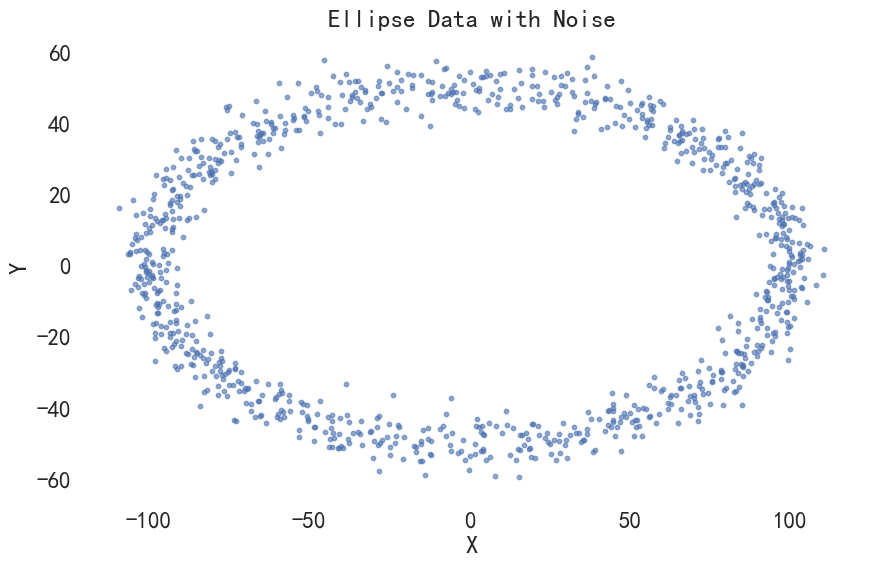

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.feature_selection import mutual_info_regression

# 生成有噪音的椭圆数据
num_points = 1000
noise_factor = 4  # 设置噪音因子
t = np.linspace(0, 2 * np.pi, num_points)
a = 100  # 长轴
b = 50  # 短轴
x = a * np.cos(t)
y = b * np.sin(t)
# 添加噪音
noise_x = np.random.normal(0, noise_factor, num_points)
noise_y = np.random.normal(0, noise_factor, num_points)
x += noise_x
y += noise_y

# 计算相关系数和互信息
pearson_corr, _ = pearsonr(x, y)
spearman_corr, _ = spearmanr(x, y)
kendall_corr, _ = kendalltau(x, y)
mutual_info = mutual_info_regression(x.reshape(-1, 1), y)[0]

# 打印结果
print("Pearson相关系数:", pearson_corr)
print("Spearman相关系数:", spearman_corr)
print("Kendall相关系数:", kendall_corr)
print("互信息:", mutual_info)

# 可视化数据
plt.figure(figsize=(10, 6), facecolor='white')  # 设置背景为白色
plt.scatter(x, y, alpha=0.6, s=10)
plt.title('Ellipse Data with Noise')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()


Pearson相关系数: 0.0006544038283411353
Spearman相关系数: 0.002216822216822217
Kendall相关系数: 0.00188988988988989
互信息: 1.660886557894055


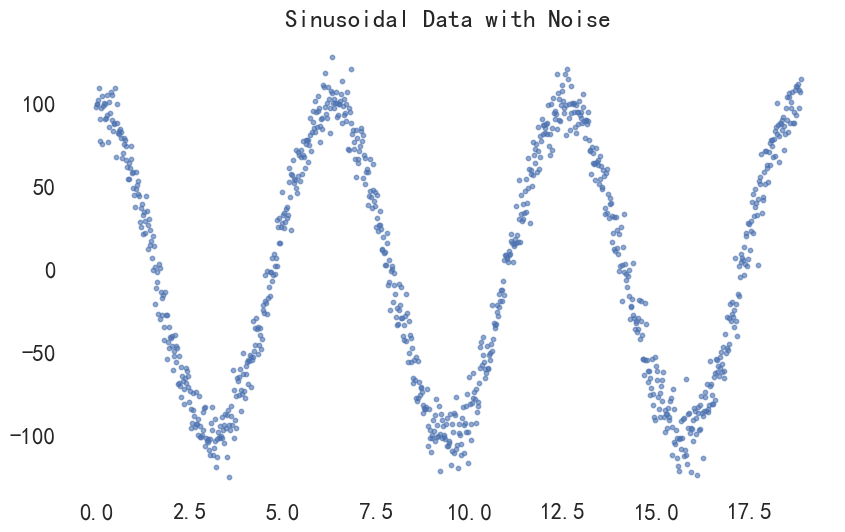

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.feature_selection import mutual_info_regression

# 设置matplotlib的背景颜色为白色
plt.rcParams['axes.facecolor'] = 'white'

# 生成正弦波数据
num_points = 1000
noise_factor = 10  # 噪音因子
x = np.linspace(0, 6 * np.pi, num_points)
y_wave = 100 * np.cos(x)
noise = np.random.normal(0, noise_factor, num_points)
y = y_wave + noise

# 计算相关系数和互信息
pearson_corr, _ = pearsonr(x, y)
spearman_corr, _ = spearmanr(x, y)
kendall_corr, _ = kendalltau(x, y)
mutual_info = mutual_info_regression(x.reshape(-1, 1), y)[0]

# 打印结果
print("Pearson相关系数:", pearson_corr)
print("Spearman相关系数:", spearman_corr)
print("Kendall相关系数:", kendall_corr)
print("互信息:", mutual_info)

# 可视化数据
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, s=10)
plt.title('Sinusoidal Data with Noise')  # 设置图表标题

# 设置x轴和y轴的可见性
plt.tick_params(axis='both', which='both', length=0)  # 不显示刻度线

# 关闭网格线
plt.grid(False)

# 显示图形
plt.show()

Pearson相关系数: -0.012656592026822275
Spearman相关系数: -0.005028502850285028
Kendall相关系数: -0.004444444444444445
互信息: 1.6963638035536195


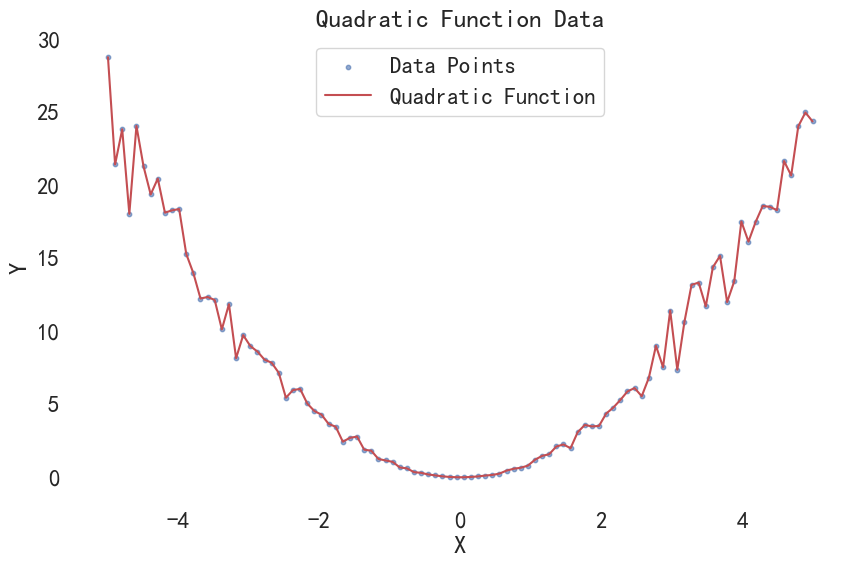

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.feature_selection import mutual_info_regression

# 设置matplotlib的背景颜色为白色
plt.rcParams['axes.facecolor'] = 'white'

# 生成二次函数数据
num_points = 100
x = np.linspace(-5, 5, num_points)
# 二次函数 y = ax^2 + bx + c，这里 a=1, b=0, c=0
y = x**2

# 添加一些噪声
noise = np.random.normal(0, 0.1 * np.abs(y), num_points)  # 噪声与y值的大小成比例
y += noise

# 计算相关系数和互信息
# 由于是二次函数，与自身的相关性应该是1
pearson_corr, _ = pearsonr(x, y)
spearman_corr, _ = spearmanr(x, y)
kendall_corr, _ = kendalltau(x, y)
mutual_info = mutual_info_regression(x.reshape(-1, 1), y)[0]

# 打印结果
print("Pearson相关系数:", pearson_corr)
print("Spearman相关系数:", spearman_corr)
print("Kendall相关系数:", kendall_corr)
print("互信息:", mutual_info)

# 可视化数据
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, s=10, label='Data Points')
plt.plot(x, y, 'r-', label='Quadratic Function')  # 绘制二次函数曲线
plt.title('Quadratic Function Data')  # 设置图表标题
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()  # 显示图例
plt.grid(False)  # 关闭网格线

# 显示图形
plt.show()

Pearson相关系数: 0.004467726332557679
Spearman相关系数: 0.0040012120012120015
Kendall相关系数: 0.0014694694694694695
互信息: 1.0112983686141144


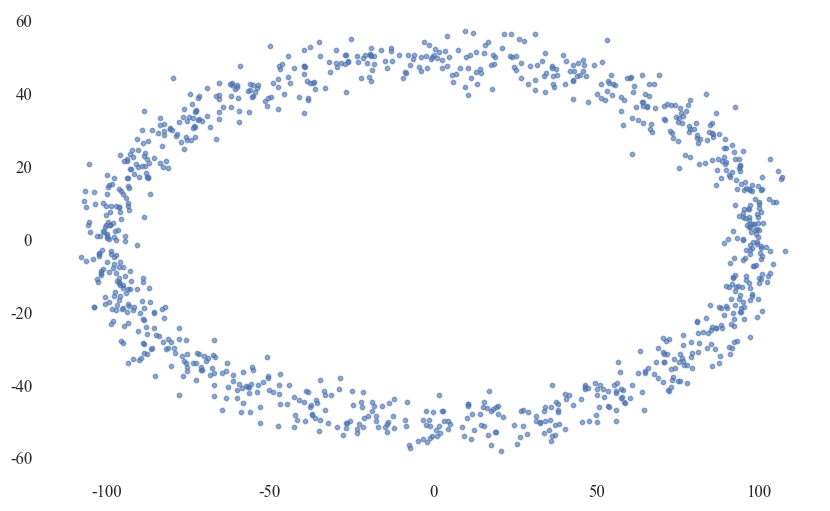

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.feature_selection import mutual_info_regression

# 生成有噪音的椭圆数据
num_points = 1000
noise_factor = 4  # 设置噪音因子
t = np.linspace(0, 2 * np.pi, num_points)
a = 100  # 长轴
b = 50  # 短轴
x = a * np.cos(t)
y = b * np.sin(t)
# 添加噪音
noise_x = np.random.normal(0, noise_factor, num_points)
noise_y = np.random.normal(0, noise_factor, num_points)
x += noise_x
y += noise_y

# 计算相关系数和互信息
pearson_corr, _ = pearsonr(x, y)
spearman_corr, _ = spearmanr(x, y)
kendall_corr, _ = kendalltau(x, y)
mutual_info = mutual_info_regression(x.reshape(-1, 1), y)[0]

# 打印结果
print("Pearson相关系数:", pearson_corr)
print("Spearman相关系数:", spearman_corr)
print("Kendall相关系数:", kendall_corr)
print("互信息:", mutual_info)

# 设置字体为Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# 可视化数据
plt.figure(figsize=(10, 6), facecolor='white')  # 设置背景为白色
plt.scatter(x, y, alpha=0.6, s=10)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


Pearson相关系数: -0.0004754413044438556
Spearman相关系数: 0.0001776841776841777
Kendall相关系数: 0.0014614614614614615
互信息: 1.8193161478173647


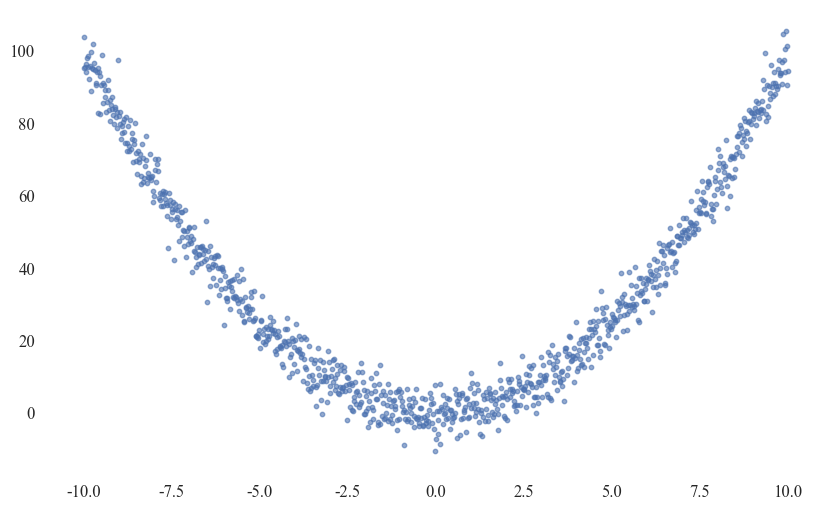

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.feature_selection import mutual_info_regression

# 生成有噪音的二次函数数据
num_points = 1000
noise_factor = 4  # 设置噪音因子
x = np.linspace(-10, 10, num_points)
y_quadratic = x**2
# 添加噪音
noise = np.random.normal(0, noise_factor, num_points)
y = y_quadratic + noise

# 计算相关系数和互信息
pearson_corr, _ = pearsonr(x, y)
spearman_corr, _ = spearmanr(x, y)
kendall_corr, _ = kendalltau(x, y)
mutual_info = mutual_info_regression(x.reshape(-1, 1), y)[0]

# 打印结果
print("Pearson相关系数:", pearson_corr)
print("Spearman相关系数:", spearman_corr)
print("Kendall相关系数:", kendall_corr)
print("互信息:", mutual_info)

# 设置字体为Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# 可视化数据
plt.figure(figsize=(10, 6), facecolor='white')  # 设置背景为白色
plt.scatter(x, y, alpha=0.6, s=10)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


Pearson相关系数: 0.779
Spearman相关系数: 0.864
Kendall相关系数: 0.714
互信息: 1.413


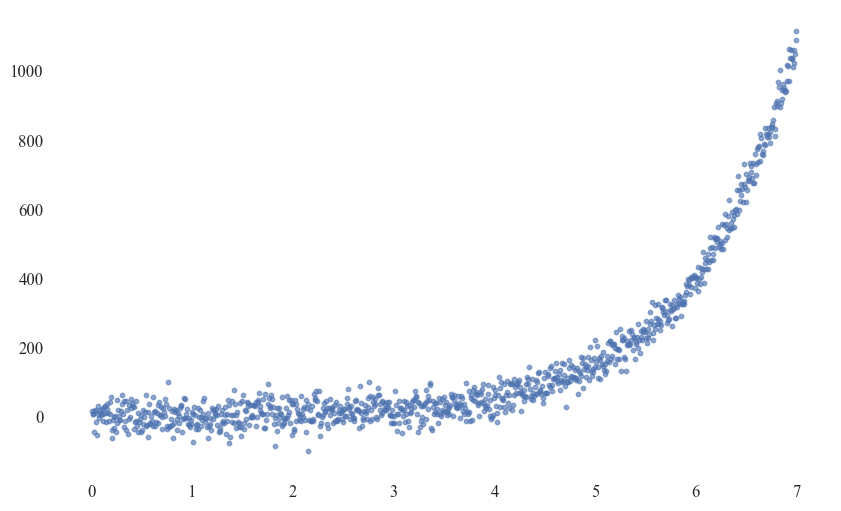

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.feature_selection import mutual_info_regression

# 生成有噪音的指数函数数据
num_points = 1000
noise_factor = 30  # 设置噪音因子
x = np.linspace(0, 7, num_points)
y_exponential = np.exp(x)
# 添加噪音
noise = np.random.normal(0, noise_factor, num_points)
y = y_exponential + noise

# 计算相关系数和互信息
pearson_corr, _ = pearsonr(x, y)
spearman_corr, _ = spearmanr(x, y)
kendall_corr, _ = kendalltau(x, y)
mutual_info = mutual_info_regression(x.reshape(-1, 1), y)[0]
# 保留小数点后三位
pearson_corr = round(pearson_corr, 3)
spearman_corr = round(spearman_corr, 3)
kendall_corr = round(kendall_corr, 3)
mutual_info = round(mutual_info, 3)

# 打印结果
print("Pearson相关系数:", pearson_corr)
print("Spearman相关系数:", spearman_corr)
print("Kendall相关系数:", kendall_corr)
print("互信息:", mutual_info)

# 设置字体为Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# 可视化数据
plt.figure(figsize=(10, 6), facecolor='white')  # 设置背景为白色
plt.scatter(x, y, alpha=0.6, s=10)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


Pearson相关系数: 0.996
Spearman相关系数: 0.996
Kendall相关系数: 0.945
互信息: 2.367


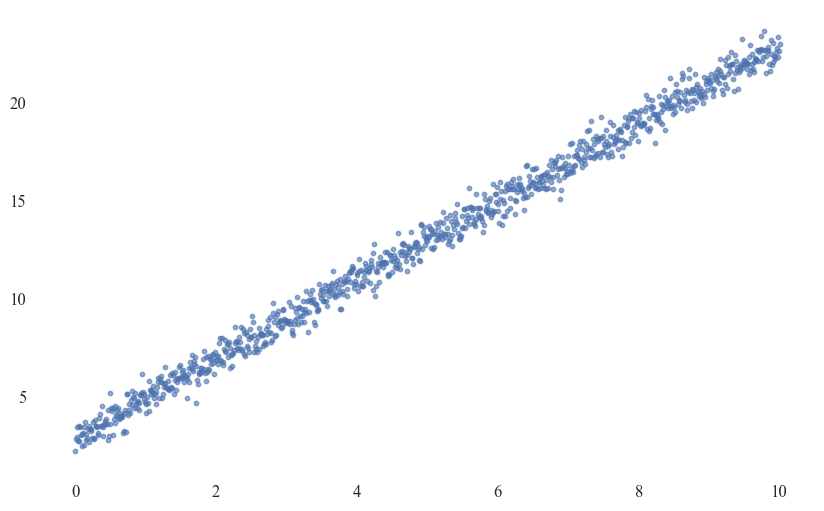

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.feature_selection import mutual_info_regression

# 生成有噪音的线性函数数据
num_points = 1000
noise_factor = 0.5  # 设置噪音因子
x = np.linspace(0, 10, num_points)
y_linear = 2 * x + 3  # 线性函数 y = 2x + 3
# 添加噪音
noise = np.random.normal(0, noise_factor, num_points)
y = y_linear + noise

# 计算相关系数和互信息
pearson_corr, _ = pearsonr(x, y)
spearman_corr, _ = spearmanr(x, y)
kendall_corr, _ = kendalltau(x, y)
mutual_info = mutual_info_regression(x.reshape(-1, 1), y)[0]
# 保留小数点后三位
pearson_corr = round(pearson_corr, 3)
spearman_corr = round(spearman_corr, 3)
kendall_corr = round(kendall_corr, 3)
mutual_info = round(mutual_info, 3)

# 打印结果
print("Pearson相关系数:", pearson_corr)
print("Spearman相关系数:", spearman_corr)
print("Kendall相关系数:", kendall_corr)
print("互信息:", mutual_info)

# 设置字体为Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# 可视化数据
plt.figure(figsize=(10, 6), facecolor='white')  # 设置背景为白色
plt.scatter(x, y, alpha=0.6, s=10)


plt.grid(True)  # 启用网格线

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


Pearson相关系数: 0.002
Spearman相关系数: 0.012
Kendall相关系数: 0.008
互信息: 0.022


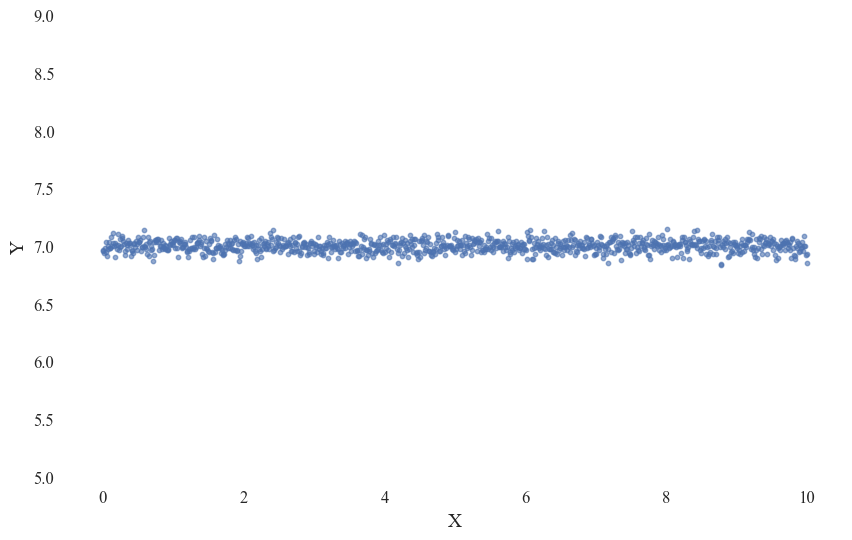

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.feature_selection import mutual_info_regression

# 生成有噪音的常数数据
num_points = 1000
noise_factor = 0.05  # 设置噪音因子
x = np.linspace(0, 10, num_points)
y_constant = 7  # 常数值
# 添加噪音
noise = np.random.normal(0, noise_factor, num_points)
y = y_constant + noise

# 计算相关系数和互信息
pearson_corr, _ = pearsonr(x, y)
spearman_corr, _ = spearmanr(x, y)
kendall_corr, _ = kendalltau(x, y)
mutual_info = mutual_info_regression(x.reshape(-1, 1), y)[0]

# 保留小数点后三位
pearson_corr = round(pearson_corr, 3)
spearman_corr = round(spearman_corr, 3)
kendall_corr = round(kendall_corr, 3)
mutual_info = round(mutual_info, 3)

# 打印结果
print("Pearson相关系数:", pearson_corr)
print("Spearman相关系数:", spearman_corr)
print("Kendall相关系数:", kendall_corr)
print("互信息:", mutual_info)

# 设置字体为Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# 可视化数据
plt.figure(figsize=(10, 6), facecolor='white')  # 设置背景为白色
plt.scatter(x, y, alpha=0.6, s=10)

plt.xlabel('X', fontsize=14)
plt.ylabel('Y', fontsize=14)
plt.ylim(5, 9)  # 设置y轴显示范围
plt.grid(True)  # 启用网格线
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


Pearson相关系数: 0.894
Spearman相关系数: 0.968
Kendall相关系数: 0.852
互信息: 1.583


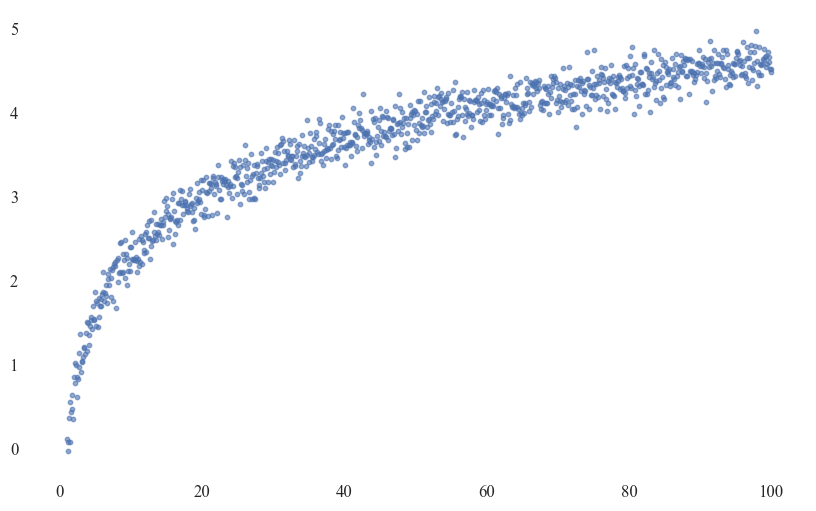

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.feature_selection import mutual_info_regression

# 生成有噪音的对数函数数据
num_points = 1000
noise_factor = 0.15  # 设置噪音因子
x = np.linspace(1, 100, num_points)  # 对数函数的输入不能为0，所以从1开始
y_logarithmic = np.log(x)
# 添加噪音
noise = np.random.normal(0, noise_factor, num_points)
y = y_logarithmic + noise

# 计算相关系数和互信息
pearson_corr, _ = pearsonr(x, y)
spearman_corr, _ = spearmanr(x, y)
kendall_corr, _ = kendalltau(x, y)
mutual_info = mutual_info_regression(x.reshape(-1, 1), y)[0]
# 保留小数点后三位
pearson_corr = round(pearson_corr, 3)
spearman_corr = round(spearman_corr, 3)
kendall_corr = round(kendall_corr, 3)
mutual_info = round(mutual_info, 3)

# 打印结果
print("Pearson相关系数:", pearson_corr)
print("Spearman相关系数:", spearman_corr)
print("Kendall相关系数:", kendall_corr)
print("互信息:", mutual_info)

# 设置字体为Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# 可视化数据
plt.figure(figsize=(10, 6), facecolor='white')  # 设置背景为白色
plt.scatter(x, y, alpha=0.6, s=10)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


In [93]:
import pandas as pd
import statsmodels.api as sm

# 读取数据集
file_path = 'F:/zhoumian/book/Concrete_Data_Yeh.csv'
data = pd.read_csv(file_path)

# 确认数据集列名
print(data.columns)

# 设置自变量和因变量
X = data.drop('csMPa', axis=1)  # 自变量
Y = data['csMPa']               # 因变量

# 添加常数项
X = sm.add_constant(X)

# 构建模型
model = sm.OLS(Y, X).fit()

# 打印模型检验结果
print(model.summary())


Index(['cement', 'slag', 'flyash', 'water', 'superplasticizer',
       'coarseaggregate', 'fineaggregate', 'age', 'csMPa'],
      dtype='object')
                            OLS Regression Results                            
Dep. Variable:                  csMPa   R-squared:                       0.616
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     204.3
Date:                Tue, 16 Jul 2024   Prob (F-statistic):          6.29e-206
Time:                        19:05:55   Log-Likelihood:                -3869.0
No. Observations:                1030   AIC:                             7756.
Df Residuals:                    1021   BIC:                             7800.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|    

In [1]:
import pandas as pd

# 读取 Excel 文件
df = pd.read_excel('data_1.xlsx')

# 查看列头
print("列头:", df.columns)

# 查看前三列
print("前三列数据:")
print(df.iloc[:, :3])

# 查看最后两列
print("最后两列数据:")
print(df.iloc[:, -2:])


列头: Index(['X', 'y'], dtype='object')
前三列数据:
            X          y
0  -10.000000  39.820262
1   -9.797980  31.405031
2   -9.595960  32.742991
3   -9.393939  37.539636
4   -9.191919  34.199641
..        ...        ...
95   9.191919  65.162393
96   9.393939  63.963428
97   9.595960  75.162492
98   9.797980  69.230724
99  10.000000  73.009947

[100 rows x 2 columns]
最后两列数据:
            X          y
0  -10.000000  39.820262
1   -9.797980  31.405031
2   -9.595960  32.742991
3   -9.393939  37.539636
4   -9.191919  34.199641
..        ...        ...
95   9.191919  65.162393
96   9.393939  63.963428
97   9.595960  75.162492
98   9.797980  69.230724
99  10.000000  73.009947

[100 rows x 2 columns]


In [3]:
import numpy as np
import pandas as pd

# 生成示例数据
np.random.seed(0)
days = np.arange(1, 366)  # 一年的天数
sales = np.random.randint(20, 100, size=len(days))  # 每日销量

# 创建 DataFrame
df = pd.DataFrame({'Day': days, 'Sales': sales})

# 保存生成的数据为 sales_data.xlsx
df.to_excel('sales_data.xlsx', index=False)

# 展示生成的数据
print(df.head())  # 显示前五行数据
print(df.tail())  # 显示最后五行数据


   Day  Sales
0    1     64
1    2     67
2    3     84
3    4     87
4    5     87
     Day  Sales
360  361     74
361  362     45
362  363     40
363  364     77
364  365     43


In [6]:
import pandas as pd

# 读取数据
df = pd.read_excel('dataNormalization.xlsx')

# 获取前3行和后3行数据，不显示索引
first_3_rows = df.head(3).to_string(index=False)
last_3_rows = df.tail(3).to_string(index=False)

# 展示数据
print("前3行数据：")
print(first_3_rows)
print("...\n")

print(last_3_rows)


前3行数据：
        日期     真实函数     原始数据
2024-01-01 0.000000 1.764052
2024-01-02 0.334199 0.734356
2024-01-03 0.666903 1.645641
...

        日期     真实函数     原始数据
2024-10-24 4.251789 4.834742
2024-10-25 4.418138 4.018689
2024-10-26 4.564726 4.934782


In [1]:
import numpy as np
import pandas as pd

# Original data
data = [5]*259 + [6]*3 + [8]*2

# Shuffle the data to introduce randomness
np.random.shuffle(data)

# Define the percentage for each group (20%)
n = len(data)
group_size = n // 5

# Replace 20% with 0, 20% with 1, and so on
data[:group_size] = [0] * group_size
data[group_size:2*group_size] = [1] * group_size
data[2*group_size:3*group_size] = [2] * group_size
data[3*group_size:4*group_size] = [3] * group_size
data[4*group_size:] = [4] * (n - 4*group_size)

# Shuffle the data again for randomness
np.random.shuffle(data)

# Convert to DataFrame for display
df = pd.DataFrame(data, columns=['Interaction_Count'])

import ace_tools as tools; tools.display_dataframe_to_user(name="Transformed Data", dataframe=df)


ModuleNotFoundError: No module named 'ace_tools'